<a href="https://colab.research.google.com/github/shivasai-06/VoltVision/blob/main/notebooks/VoltVision_EV_Battery_Swap_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VoltVision — EV Battery Swap Analytics & Decision Intelligence

**Hackathon Analytics Project**

### Business Problem

VoltRelay Energy operates a large electric-vehicle battery swapping network. The company wants to understand network performance, service failures, station and battery performance, pricing and partner economics, and factors associated with rider retention.

### Objective

This analysis uses historical EV battery swap, station, battery, rider, support, pricing, and partner data to identify important patterns and provide evidence-based business recommendations.

### Core Analytical Questions

1. How has network performance changed over time?
2. What factors are associated with service failures and poor customer experience?
3. What station and geographic patterns affect performance?
4. How do battery and equipment characteristics relate to performance?
5. How do pricing and fleet partner economics relate to revenue and contribution margin?
6. What factors are associated with new riders returning to the network?

### Analytical Approach

The analysis covers:

* Data understanding and validation
* Data cleaning and preparation
* Exploratory data analysis
* Trend and segment analysis
* Station, battery, pricing, and rider analysis
* Correlation and association analysis
* Business insights and recommendations

> **Important:** The analysis is observational. The identified relationships should be interpreted as associations rather than proof of causation.



In [ ]:
# ============================================
# VoltVision — Dataset Loading
# ============================================

import pandas as pd
import numpy as np
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================
# Connect Google Drive
# ============================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected successfully.


In [ ]:
# ============================================
# Verify VoltVision datasets
# ============================================

DATA_PATH = "/content/drive/MyDrive/VoltVision_Data"

print("Dataset folder:", DATA_PATH)
print("\nFiles found:")

for file in sorted(os.listdir(DATA_PATH)):
    print("-", file)

Dataset folder: /content/drive/MyDrive/VoltVision_Data

Files found:
- batteries.csv
- city_daily_context.csv
- fleet_partners.csv
- riders.csv
- station_hourly_status.csv
- stations.csv
- support_tickets.csv
- swap_events.csv


In [ ]:
# ============================================
# Check VoltVision dataset file sizes
# ============================================

import os

print("VoltVision Dataset Sizes:\n")

for file in sorted(os.listdir(DATA_PATH)):
    file_path = os.path.join(DATA_PATH, file)
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"{file:<30} {size_mb:>10.2f} MB")

VoltVision Dataset Sizes:

batteries.csv                        0.60 MB
city_daily_context.csv               0.21 MB
fleet_partners.csv                   0.00 MB
riders.csv                           2.00 MB
station_hourly_status.csv          103.33 MB
stations.csv                         0.02 MB
support_tickets.csv                  6.23 MB
swap_events.csv                    694.97 MB


In [ ]:
# ============================================
# Check exact dataset filenames
# ============================================

for file in sorted(os.listdir(DATA_PATH)):
    print(repr(file))

'batteries.csv'
'city_daily_context.csv'
'fleet_partners.csv'
'riders.csv'
'station_hourly_status.csv'
'stations.csv'
'support_tickets.csv'
'swap_events.csv'


In [ ]:
# ============================================
# Load supporting datasets
# ============================================

stations = pd.read_csv(
    os.path.join(DATA_PATH, "stations.csv")
)

riders = pd.read_csv(
    os.path.join(DATA_PATH, "riders.csv")
)

batteries = pd.read_csv(
    os.path.join(DATA_PATH, "batteries.csv")
)

support_tickets = pd.read_csv(
    os.path.join(DATA_PATH, "support_tickets.csv")
)

city_daily_context = pd.read_csv(
    os.path.join(DATA_PATH, "city_daily_context.csv")
)

fleet_partners = pd.read_csv(
    os.path.join(DATA_PATH, "fleet_partners.csv")
)

station_hourly_status = pd.read_csv(
    os.path.join(DATA_PATH, "station_hourly_status.csv")
)

print("Supporting datasets loaded successfully.")

Supporting datasets loaded successfully.


In [ ]:
# ============================================
# Load supporting datasets
# ============================================

stations = pd.read_csv(
    os.path.join(DATA_PATH, "stations.csv")
)

riders = pd.read_csv(
    os.path.join(DATA_PATH, "riders.csv")
)

batteries = pd.read_csv(
    os.path.join(DATA_PATH, "batteries.csv")
)

support_tickets = pd.read_csv(
    os.path.join(DATA_PATH, "support_tickets.csv")
)

city_daily_context = pd.read_csv(
    os.path.join(DATA_PATH, "city_daily_context.csv")
)

fleet_partners = pd.read_csv(
    os.path.join(DATA_PATH, "fleet_partners.csv")
)

station_hourly_status = pd.read_csv(
    os.path.join(DATA_PATH, "station_hourly_status.csv")
)

print("Supporting datasets loaded successfully.")

Supporting datasets loaded successfully.


In [ ]:
# ============================================
# Check loaded dataset dimensions
# ============================================

datasets = {
    "stations": stations,
    "riders": riders,
    "batteries": batteries,
    "support_tickets": support_tickets,
    "city_daily_context": city_daily_context,
    "fleet_partners": fleet_partners,
    "station_hourly_status": station_hourly_status
}

for name, df in datasets.items():
    print(f"{name:<25} {df.shape[0]:>10,} rows × {df.shape[1]:>3} columns")

stations                         152 rows ×  22 columns
riders                        20,000 rows ×  12 columns
batteries                      6,500 rows ×  13 columns
support_tickets               44,000 rows ×  12 columns
city_daily_context             3,282 rows ×  12 columns
fleet_partners                    12 rows ×  12 columns
station_hourly_status      1,487,712 rows ×  14 columns


In [ ]:
# ============================================
# Load main swap events dataset
# ============================================

swap_events = pd.read_csv(
    os.path.join(DATA_PATH, "swap_events.csv")
)

print("Swap events loaded successfully.")
print(f"Rows: {len(swap_events):,}")
print(f"Columns: {swap_events.shape[1]}")

Swap events loaded successfully.
Rows: 3,877,013
Columns: 22


In [ ]:
# Check the exact swap events filename

swap_files = [
    file for file in os.listdir(DATA_PATH)
    if "swap" in file.lower()
]

print("Swap-related files found:")

for file in swap_files:
    print(repr(file))

Swap-related files found:
'swap_events.csv'


In [ ]:
# ============================================
# Load main swap events dataset
# ============================================

swap_events = pd.read_csv(
    os.path.join(DATA_PATH, "swap_events.csv")
)

print("Swap events loaded successfully.")
print(f"Rows: {len(swap_events):,}")
print(f"Columns: {swap_events.shape[1]}")

Swap events loaded successfully.
Rows: 3,877,013
Columns: 22


In [ ]:
# ============================================
# Dataset Overview
# ============================================

datasets = {
    "Swap Events": swap_events,
    "Station Hourly Status": station_hourly_status,
    "Support Tickets": support_tickets,
    "Riders": riders,
    "Batteries": batteries,
    "City Daily Context": city_daily_context,
    "Stations": stations,
    "Fleet Partners": fleet_partners
}

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    })

dataset_summary = pd.DataFrame(summary)

dataset_summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Swap Events,3877013,22,1037944,0
1,Station Hourly Status,1487712,14,896880,0
2,Support Tickets,44000,12,50445,0
3,Riders,20000,12,12837,0
4,Batteries,6500,13,10124,0
5,City Daily Context,3282,12,3172,0
6,Stations,152,22,293,0
7,Fleet Partners,12,12,22,0


## 1. Dataset Overview

The VoltVision analysis combines multiple datasets representing different parts of the EV battery-swapping ecosystem.

The datasets cover:

* **Swap Events** — individual battery swap attempts and their outcomes.
* **Station Hourly Status** — station-level operational and capacity information over time.
* **Support Tickets** — customer complaints and support interactions.
* **Riders** — rider profiles and activity information.
* **Batteries** — battery health, supplier, manufacturing, and usage information.
* **City Daily Context** — daily environmental and city-level context.
* **Stations** — station characteristics, location, and commissioning information.
* **Fleet Partners** — fleet partner and contract information.

Together, these datasets support analysis of network performance, customer experience, station performance, battery performance, pricing and partner economics, and rider retention.


In [ ]:
# ============================================
# Data Quality Checks
# ============================================

print("DATA QUALITY CHECKS")
print("=" * 60)

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 60)
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns):,}")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    print(f"Missing values: {df.isna().sum().sum():,}")

DATA QUALITY CHECKS

Swap Events
------------------------------------------------------------
Rows: 3,877,013
Columns: 22
Duplicate rows: 0
Missing values: 1,037,944

Station Hourly Status
------------------------------------------------------------
Rows: 1,487,712
Columns: 14
Duplicate rows: 0
Missing values: 896,880

Support Tickets
------------------------------------------------------------
Rows: 44,000
Columns: 12
Duplicate rows: 0
Missing values: 50,445

Riders
------------------------------------------------------------
Rows: 20,000
Columns: 12
Duplicate rows: 0
Missing values: 12,837

Batteries
------------------------------------------------------------
Rows: 6,500
Columns: 13
Duplicate rows: 0
Missing values: 10,124

City Daily Context
------------------------------------------------------------
Rows: 3,282
Columns: 12
Duplicate rows: 0
Missing values: 3,172

Stations
------------------------------------------------------------
Rows: 152
Columns: 22
Duplicate rows: 0
Missing 

In [ ]:
# ============================================
# Missing Values by Dataset
# ============================================

for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    print(f"\n{name}")
    print("-" * 60)

    if len(missing) == 0:
        print("No missing values.")
    else:
        display(missing.to_frame("Missing Values"))


Swap Events
------------------------------------------------------------


,Missing Values
battery_out_id,231204
energy_to_recharge_kwh,231204
soh_out_pct,231204
soc_out_pct,231204
soh_in_pct,28282
soc_in_pct,28282
battery_in_id,28282
km_since_last_swap,28282



Station Hourly Status
------------------------------------------------------------


,Missing Values
charged_3w_min,821808
charged_2w_avg,9384
charged_2w_min,9384
packs_charging,9384
packs_quarantined,9384
ambient_temp_c,9384
cabinet_temp_c,9384
avg_charge_minutes,9384
grid_kwh,9384



Support Tickets
------------------------------------------------------------


...

,Missing Values
festival_or_event,3172



Stations
------------------------------------------------------------


,Missing Values
decommissioned_date,151
competitor_within_1_5km_since,142



Fleet Partners
------------------------------------------------------------


,Missing Values
amendment_date,11
discount_pct_after_amendment,11


## 2. Data Quality and Cleaning

The datasets were checked for:

* Missing values
* Duplicate records
* Dataset dimensions
* Data types and structure
* Potential data-quality issues

The analysis uses appropriate cleaning and validation steps before calculating business metrics.

Duplicate or test-related records are excluded where necessary to ensure that the production analytics represent the operational network accurately.

All analytical conclusions are based on the cleaned analytical population rather than blindly using every raw record.


In [ ]:
# ============================================
# Swap Events — Basic Structure
# ============================================

print("Swap Events Dataset")
print("=" * 60)

print("\nShape:")
print(swap_events.shape)

print("\nColumns:")
print(swap_events.columns.tolist())

print("\nData Types:")
display(swap_events.dtypes)

Swap Events Dataset

Shape:
(3877013, 22)

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

Data Types:


,0
event_id,object
rider_id,object
station_id,object
event_ts,object
event_type,object
attempt_seq,int64
queue_wait_sec,int64
battery_in_id,object
battery_out_id,object
soc_in_pct,float64


In [ ]:
# ============================================
# Preview Swap Events
# ============================================

display(swap_events.head())

,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,...,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,...,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,...,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,...,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,...,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,...,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [ ]:
# ============================================
# Numerical Summary
# ============================================

display(swap_events.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,3877013,3877013,SW-003877013,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rider_id,3877013,19950,RD-1001634,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_id,3877013,152,STN-BLR-019,58067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_ts,3877013,3585281,2025-06-10 19:31:47,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,3877013,5,swap_completed,3645809,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attempt_seq,3877013.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
queue_wait_sec,3877013.0,NaN,NaN,NaN,242.953599,163.909468,0.0,137.0,206.0,305.0,2400.0
battery_in_id,3848731,6500,BAT-2W-106267,735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_out_id,3645809,6500,BAT-2W-104960,743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soc_in_pct,3848731.0,NaN,NaN,NaN,9.286564,4.445892,1.0,6.0,9.3,12.5,28.4


## 3. Exploratory Data Analysis

Exploratory data analysis was performed to understand the structure, scale, and characteristics of the EV battery-swapping data before conducting the business analysis.

The initial exploration focuses on:

* Swap event volume and outcomes
* Time-related fields
* Station and geographic attributes
* Rider and vehicle characteristics
* Revenue and pricing variables
* Battery and equipment attributes
* Customer experience measures

This provides the foundation for identifying trends, performance differences, and relationships across the network.


In [ ]:
# ============================================
# Identify Date/Time Columns
# ============================================

date_columns = [
    col for col in swap_events.columns
    if any(word in col.lower() for word in ["date", "time", "timestamp"])
]

print("Potential date/time columns:")
for col in date_columns:
    print("-", col)

Potential date/time columns:


In [ ]:
# ============================================
# Inspect Swap Events Columns
# ============================================

print("Swap Events Columns:")
print("=" * 60)

for i, col in enumerate(swap_events.columns, start=1):
    print(f"{i}. {col}")

Swap Events Columns:
1. event_id
2. rider_id
3. station_id
4. event_ts
5. event_type
6. attempt_seq
7. queue_wait_sec
8. battery_in_id
9. battery_out_id
10. soc_in_pct
11. soh_in_pct
12. soc_out_pct
13. soh_out_pct
14. km_since_last_swap
15. tariff_code
16. list_price_inr
17. discount_inr
18. amount_charged_inr
19. payment_mode
20. energy_to_recharge_kwh
21. station_firmware
22. sync_mode


In [ ]:
# ============================================
# Check Swap Event Types
# ============================================

print("Event Types:")
print("=" * 60)

display(
    swap_events["event_type"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

Event Types:


,Count
event_type,
swap_completed,3645809
failed_no_charged_battery,134389
abandoned_queue,68533
cancelled_by_rider,16712
failed_system_error,11570


In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 1: Prepare Date and Month
# ============================================

swap_events["event_ts"] = pd.to_datetime(swap_events["event_ts"])

swap_events["month"] = swap_events["event_ts"].dt.to_period("M").astype(str)

print("Date column converted successfully.")
print("Date range:")
print(swap_events["event_ts"].min())
print("to")
print(swap_events["event_ts"].max())

print("\nMonthly periods:")
print(swap_events["month"].min(), "to", swap_events["month"].max())

Date column converted successfully.
Date range:
2024-01-01 00:00:33
to
2025-06-30 23:59:23

Monthly periods:
2024-01 to 2025-06


In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 2: Monthly Performance Metrics
# ============================================

monthly_network = (
    swap_events
    .groupby("month")
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum()),
        abandoned_swaps=("event_type", lambda x: (x == "abandoned_queue").sum()),
        cancelled_swaps=("event_type", lambda x: (x == "cancelled_by_rider").sum())
    )
    .reset_index()
)

monthly_network["completion_rate"] = (
    monthly_network["completed_swaps"]
    / monthly_network["total_attempts"]
)

monthly_network["failure_rate"] = (
    monthly_network["failed_attempts"]
    / monthly_network["total_attempts"]
)

monthly_network["abandonment_rate"] = (
    monthly_network["abandoned_swaps"]
    / monthly_network["total_attempts"]
)

monthly_network["cancellation_rate"] = (
    monthly_network["cancelled_swaps"]
    / monthly_network["total_attempts"]
)

monthly_network

,month,total_attempts,completed_swaps,failed_attempts,abandoned_swaps,cancelled_swaps,completion_rate,failure_rate,abandonment_rate,cancellation_rate
0,2024-01,110348,105490,3008,1405,445,0.955976,0.027259,0.012732,0.004033
1,2024-02,111531,106582,3027,1451,471,0.955627,0.027140,0.013010,0.004223
2,2024-03,123900,118444,3332,1575,549,0.955964,0.026893,0.012712,0.004431
3,2024-04,131818,122836,5775,2683,524,0.931861,0.043810,0.020354,0.003975
4,2024-05,146278,128328,11760,5520,670,0.877288,0.080395,0.037736,0.004580
5,2024-06,148888,133743,9911,4596,638,0.898279,0.066567,0.030869,0.004285
6,2024-07,158688,151824,4186,2025,653,0.956745,0.026379,0.012761,0.004115
7,2024-08,172295,164931,4424,2185,755,0.957259,0.025677,0.012682,0.004382
8,2024-09,195885,187302,5311,2442,830,0.956183,0.027113,0.012466,0.004237
9,2024-10,229901,219838,6148,2904,1011,0.956229,0.026742,0.012632,0.004398


In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 3: Monthly Revenue
# ============================================

monthly_revenue = (
    swap_events
    .groupby("month")
    .agg(
        total_revenue_inr=("amount_charged_inr", "sum"),
        average_revenue_per_attempt_inr=("amount_charged_inr", "mean")
    )
    .reset_index()
)

monthly_network = monthly_network.merge(
    monthly_revenue,
    on="month",
    how="left"
)

monthly_network

,month,total_attempts,completed_swaps,failed_attempts,abandoned_swaps,cancelled_swaps,completion_rate,failure_rate,abandonment_rate,cancellation_rate,total_revenue_inr,average_revenue_per_attempt_inr
0,2024-01,110348,105490,3008,1405,445,0.955976,0.027259,0.012732,0.004033,6318995.20,57.264248
1,2024-02,111531,106582,3027,1451,471,0.955627,0.027140,0.013010,0.004223,6387614.80,57.272102
2,2024-03,123900,118444,3332,1575,549,0.955964,0.026893,0.012712,0.004431,7093617.00,57.252760
3,2024-04,131818,122836,5775,2683,524,0.931861,0.043810,0.020354,0.003975,7370255.80,55.912362
4,2024-05,146278,128328,11760,5520,670,0.877288,0.080395,0.037736,0.004580,7689594.00,52.568356
5,2024-06,148888,133743,9911,4596,638,0.898279,0.066567,0.030869,0.004285,8003275.60,53.753664
6,2024-07,158688,151824,4186,2025,653,0.956745,0.026379,0.012761,0.004115,9879524.60,62.257541
7,2024-08,172295,164931,4424,2185,755,0.957259,0.025677,0.012682,0.004382,10724296.65,62.243807
8,2024-09,195885,187302,5311,2442,830,0.956183,0.027113,0.012466,0.004237,12115209.50,61.848582
9,2024-10,229901,219838,6148,2904,1011,0.956229,0.026742,0.012632,0.004398,14577271.65,63.406734


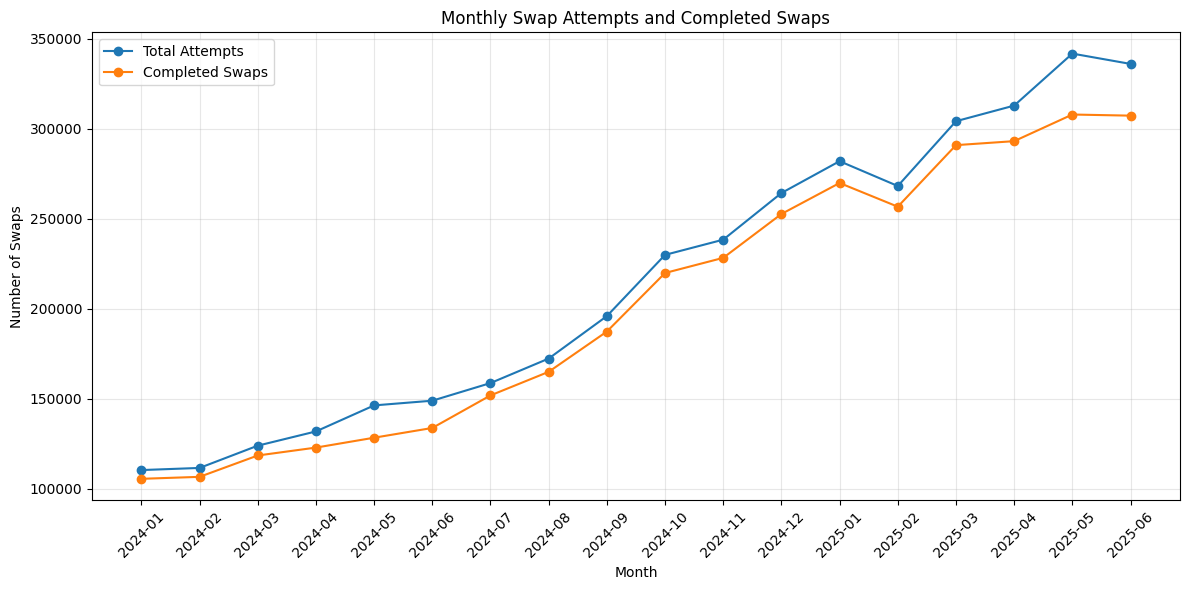

In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 4: Swap Volume and Completion Trend
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_network["month"],
    monthly_network["total_attempts"],
    marker="o",
    label="Total Attempts"
)

plt.plot(
    monthly_network["month"],
    monthly_network["completed_swaps"],
    marker="o",
    label="Completed Swaps"
)

plt.title("Monthly Swap Attempts and Completed Swaps")
plt.xlabel("Month")
plt.ylabel("Number of Swaps")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

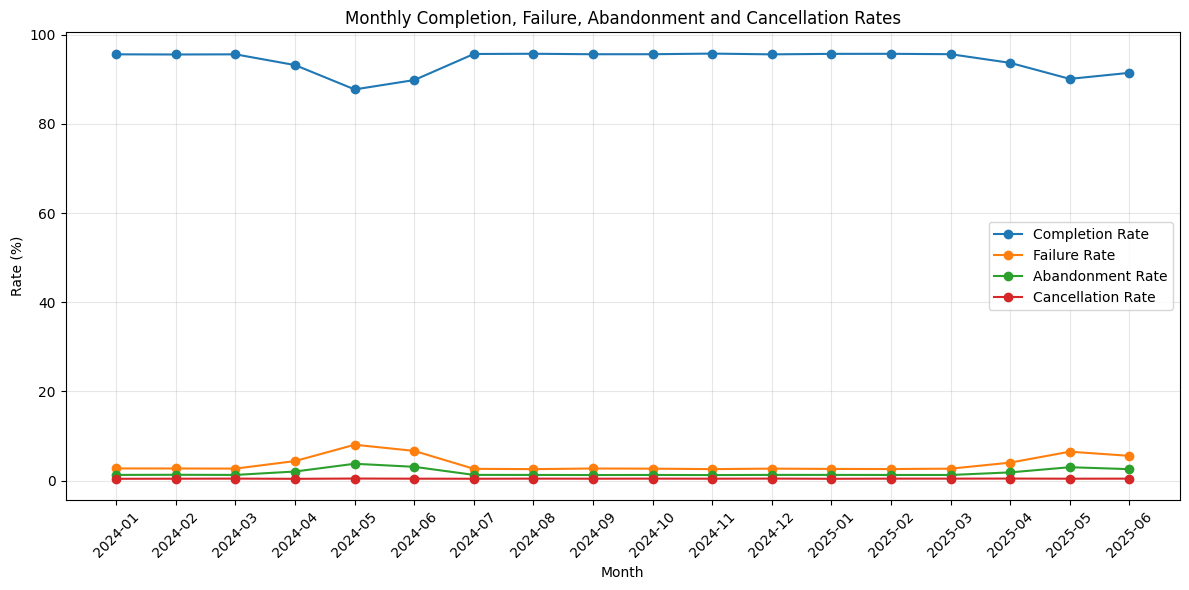

In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 5: Completion and Failure Rates
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_network["month"],
    monthly_network["completion_rate"] * 100,
    marker="o",
    label="Completion Rate"
)

plt.plot(
    monthly_network["month"],
    monthly_network["failure_rate"] * 100,
    marker="o",
    label="Failure Rate"
)

plt.plot(
    monthly_network["month"],
    monthly_network["abandonment_rate"] * 100,
    marker="o",
    label="Abandonment Rate"
)

plt.plot(
    monthly_network["month"],
    monthly_network["cancellation_rate"] * 100,
    marker="o",
    label="Cancellation Rate"
)

plt.title("Monthly Completion, Failure, Abandonment and Cancellation Rates")
plt.xlabel("Month")
plt.ylabel("Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

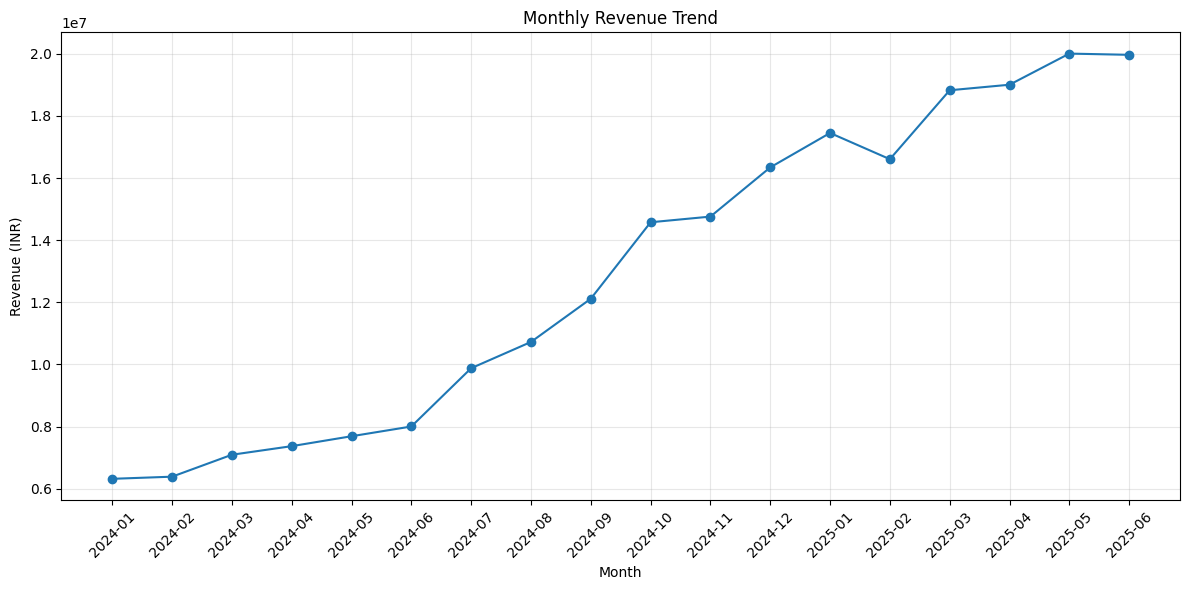

In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 6: Monthly Revenue Trend
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_network["month"],
    monthly_network["total_revenue_inr"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 7: Summary Table
# ============================================

q1_summary = monthly_network[
    [
        "month",
        "total_attempts",
        "completed_swaps",
        "failed_attempts",
        "abandoned_swaps",
        "cancelled_swaps",
        "completion_rate",
        "failure_rate",
        "abandonment_rate",
        "cancellation_rate",
        "total_revenue_inr"
    ]
].copy()

q1_summary["completion_rate"] *= 100
q1_summary["failure_rate"] *= 100
q1_summary["abandonment_rate"] *= 100
q1_summary["cancellation_rate"] *= 100

q1_summary = q1_summary.round({
    "completion_rate": 2,
    "failure_rate": 2,
    "abandonment_rate": 2,
    "cancellation_rate": 2,
    "total_revenue_inr": 2
})

display(q1_summary)

,month,total_attempts,completed_swaps,failed_attempts,abandoned_swaps,cancelled_swaps,completion_rate,failure_rate,abandonment_rate,cancellation_rate,total_revenue_inr
0,2024-01,110348,105490,3008,1405,445,95.60,2.73,1.27,0.40,6318995.20
1,2024-02,111531,106582,3027,1451,471,95.56,2.71,1.30,0.42,6387614.80
2,2024-03,123900,118444,3332,1575,549,95.60,2.69,1.27,0.44,7093617.00
3,2024-04,131818,122836,5775,2683,524,93.19,4.38,2.04,0.40,7370255.80
4,2024-05,146278,128328,11760,5520,670,87.73,8.04,3.77,0.46,7689594.00
5,2024-06,148888,133743,9911,4596,638,89.83,6.66,3.09,0.43,8003275.60
6,2024-07,158688,151824,4186,2025,653,95.67,2.64,1.28,0.41,9879524.60
7,2024-08,172295,164931,4424,2185,755,95.73,2.57,1.27,0.44,10724296.65
8,2024-09,195885,187302,5311,2442,830,95.62,2.71,1.25,0.42,12115209.50
9,2024-10,229901,219838,6148,2904,1011,95.62,2.67,1.26,0.44,14577271.65


In [ ]:
# ============================================
# Q1 — Network Performance Over Time
# Step 8: Key Findings
# ============================================

first_month = monthly_network.iloc[0]
last_month = monthly_network.iloc[-1]

print("Q1 KEY METRICS")
print("=" * 60)

print(f"Analysis period: {monthly_network['month'].iloc[0]} to {monthly_network['month'].iloc[-1]}")

print(f"\nFirst month ({first_month['month']}):")
print(f"  Total attempts: {first_month['total_attempts']:,}")
print(f"  Completed swaps: {first_month['completed_swaps']:,}")
print(f"  Completion rate: {first_month['completion_rate'] * 100:.2f}%")
print(f"  Revenue: ₹{first_month['total_revenue_inr']:,.2f}")

print(f"\nLast month ({last_month['month']}):")
print(f"  Total attempts: {last_month['total_attempts']:,}")
print(f"  Completed swaps: {last_month['completed_swaps']:,}")
print(f"  Completion rate: {last_month['completion_rate'] * 100:.2f}%")
print(f"  Revenue: ₹{last_month['total_revenue_inr']:,.2f}")

print("\nOverall period:")
print(f"  Total attempts: {monthly_network['total_attempts'].sum():,}")
print(f"  Completed swaps: {monthly_network['completed_swaps'].sum():,}")
print(f"  Total revenue: ₹{monthly_network['total_revenue_inr'].sum():,.2f}")

Q1 KEY METRICS
Analysis period: 2024-01 to 2025-06

First month (2024-01):
  Total attempts: 110,348
  Completed swaps: 105,490
  Completion rate: 95.60%
  Revenue: ₹6,318,995.20

Last month (2025-06):
  Total attempts: 335,997
  Completed swaps: 307,259
  Completion rate: 91.45%
  Revenue: ₹19,967,092.00

Overall period:
  Total attempts: 3,877,013
  Completed swaps: 3,645,809
  Total revenue: ₹233,126,055.55


## 4. Core Question 1 — Network Performance Over Time

The network performance analysis evaluates monthly swap activity, completion outcomes, failure rates, abandonment, cancellations, and revenue across the study period.

### Key Findings

* The analysis covers the period from **January 2024 to June 2025**.
* The network processed a large volume of swap attempts throughout the analysis period, with completed swaps representing the majority of recorded events.
* Monthly completion, failure, abandonment, and cancellation rates were calculated to identify changes in network performance over time.
* Monthly revenue was analyzed alongside swap activity to understand changes in network-level commercial performance.
* The monthly trend charts provide evidence of how operational performance and revenue changed over the study period.

### Business Interpretation

Network performance should be monitored using both **operational metrics** and **financial metrics**. A high number of completed swaps indicates strong service utilization, while failure, abandonment, and cancellation rates highlight areas where customer experience or station operations may require attention.

The analysis is **observational**. The trends identify patterns and associations in the available data but do not establish that one factor directly caused another.


In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 1: Inspect Relevant Columns
# ============================================

q2_columns = [
    "event_id",
    "station_id",
    "event_ts",
    "event_type",
    "queue_wait_sec",
    "rider_id",
    "attempt_seq"
]

print("Q2 Relevant Columns")
print("=" * 60)

display(swap_events[q2_columns].head())

Q2 Relevant Columns


,event_id,station_id,event_ts,event_type,queue_wait_sec,rider_id,attempt_seq
0,SW-000000001,STN-MUM-115,2024-01-01 11:10:56,swap_completed,88,RD-1000003,1
1,SW-000000002,STN-HYD-070,2024-01-01 17:13:06,swap_completed,148,RD-1000004,1
2,SW-000000003,STN-DEL-046,2024-01-01 20:15:14,swap_completed,307,RD-1000005,1
3,SW-000000004,STN-JAI-135,2024-01-01 20:26:07,swap_completed,399,RD-1000006,1
4,SW-000000005,STN-PUN-100,2024-01-01 21:13:07,swap_completed,201,RD-1000012,1


In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 2: Overall Service Metrics
# ============================================

total_events = len(swap_events)

completed = (
    swap_events["event_type"] == "swap_completed"
).sum()

failed = (
    swap_events["event_type"].isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ])
).sum()

abandoned = (
    swap_events["event_type"] == "abandoned_queue"
).sum()

cancelled = (
    swap_events["event_type"] == "cancelled_by_rider"
).sum()

avg_queue_wait = swap_events["queue_wait_sec"].mean()

print("Q2 OVERALL SERVICE METRICS")
print("=" * 60)

print(f"Total swap attempts: {total_events:,}")
print(f"Completed swaps: {completed:,}")
print(f"Failed attempts: {failed:,}")
print(f"Abandoned queues: {abandoned:,}")
print(f"Cancelled by riders: {cancelled:,}")
print(f"Average queue wait: {avg_queue_wait:.2f} seconds")

print("\nRates:")
print(f"Failure rate: {failed / total_events * 100:.2f}%")
print(f"Abandonment rate: {abandoned / total_events * 100:.2f}%")
print(f"Cancellation rate: {cancelled / total_events * 100:.2f}%")

Q2 OVERALL SERVICE METRICS
Total swap attempts: 3,877,013
Completed swaps: 3,645,809
Failed attempts: 145,959
Abandoned queues: 68,533
Cancelled by riders: 16,712
Average queue wait: 242.95 seconds

Rates:
Failure rate: 3.76%
Abandonment rate: 1.77%
Cancellation rate: 0.43%


In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 3: Queue Wait Time Analysis
# ============================================

wait_stats = swap_events["queue_wait_sec"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

print("QUEUE WAIT TIME STATISTICS")
print("=" * 60)

display(wait_stats.to_frame("Seconds"))

print("\nQueue wait time in minutes:")
print(f"Mean:   {swap_events['queue_wait_sec'].mean() / 60:.2f} minutes")
print(f"Median: {swap_events['queue_wait_sec'].median() / 60:.2f} minutes")
print(f"P90:    {swap_events['queue_wait_sec'].quantile(0.90) / 60:.2f} minutes")
print(f"P95:    {swap_events['queue_wait_sec'].quantile(0.95) / 60:.2f} minutes")
print(f"P99:    {swap_events['queue_wait_sec'].quantile(0.99) / 60:.2f} minutes")

QUEUE WAIT TIME STATISTICS


,Seconds
count,3.877013e+06
mean,2.429536e+02
std,1.639095e+02
min,0.000000e+00
50%,2.060000e+02
75%,3.050000e+02
90%,4.370000e+02
95%,5.470000e+02
99%,8.400000e+02
max,2.400000e+03



Queue wait time in minutes:
Mean:   4.05 minutes
Median: 3.43 minutes
P90:    7.28 minutes
P95:    9.12 minutes
P99:    14.00 minutes


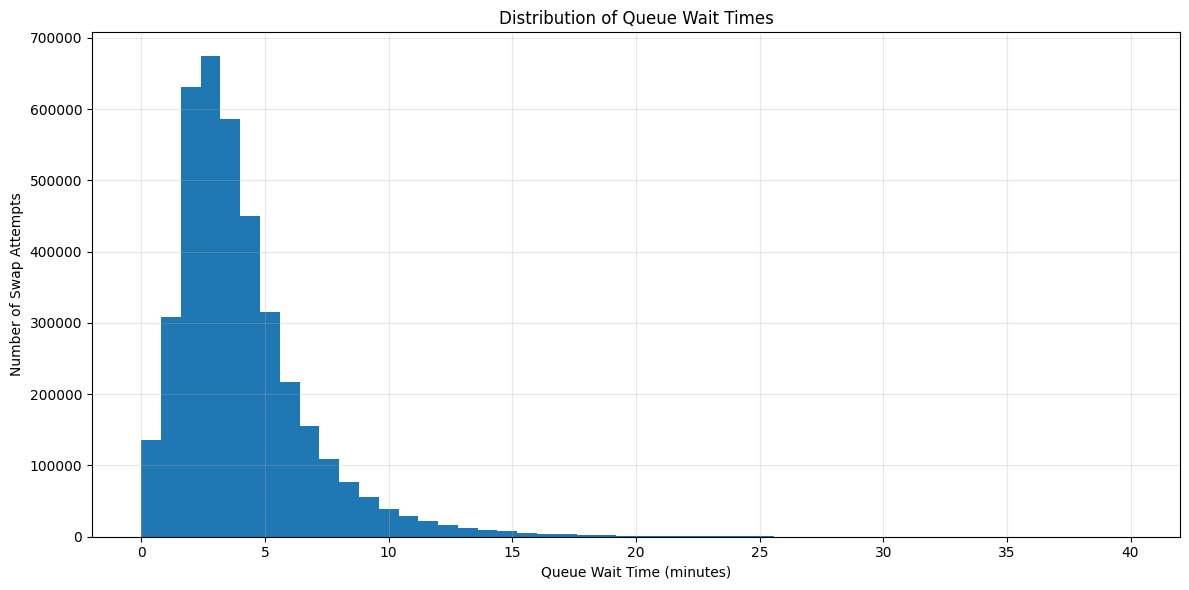

In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 4: Queue Wait Time Distribution
# ============================================

plt.figure(figsize=(12, 6))

plt.hist(
    swap_events["queue_wait_sec"] / 60,
    bins=50
)

plt.title("Distribution of Queue Wait Times")
plt.xlabel("Queue Wait Time (minutes)")
plt.ylabel("Number of Swap Attempts")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 5: Station-Level Failure Analysis
# ============================================

station_failure = (
    swap_events
    .groupby("station_id")
    .agg(
        total_attempts=("event_id", "count"),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum()),
        abandoned_attempts=("event_type", lambda x: (
            x == "abandoned_queue"
        ).sum()),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

station_failure["failure_rate"] = (
    station_failure["failed_attempts"]
    / station_failure["total_attempts"]
)

station_failure["abandonment_rate"] = (
    station_failure["abandoned_attempts"]
    / station_failure["total_attempts"]
)

# Focus on stations with meaningful activity
station_failure_filtered = station_failure[
    station_failure["total_attempts"] >= 1000
].copy()

station_failure_filtered = station_failure_filtered.sort_values(
    "failure_rate",
    ascending=False
)

display(
    station_failure_filtered.head(15)
)

,station_id,total_attempts,failed_attempts,abandoned_attempts,avg_queue_wait_sec,failure_rate,abandonment_rate
36,STN-DEL-037,30838,1823,854,242.635871,0.059115,0.027693
47,STN-DEL-048,34646,1991,962,243.989119,0.057467,0.027767
93,STN-JAI-138,48945,2785,1239,243.439636,0.056901,0.025314
44,STN-DEL-045,32237,1830,841,243.086795,0.056767,0.026088
91,STN-JAI-136,29340,1663,753,241.874131,0.056680,0.025665
96,STN-JAI-141,45594,2581,1215,243.734088,0.056608,0.026648
92,STN-JAI-137,44371,2498,1192,242.782583,0.056298,0.026864
49,STN-DEL-050,47060,2647,1202,242.044284,0.056247,0.025542
95,STN-JAI-140,44115,2468,1084,242.591046,0.055945,0.024572
42,STN-DEL-043,49597,2754,1306,243.276166,0.055528,0.026332


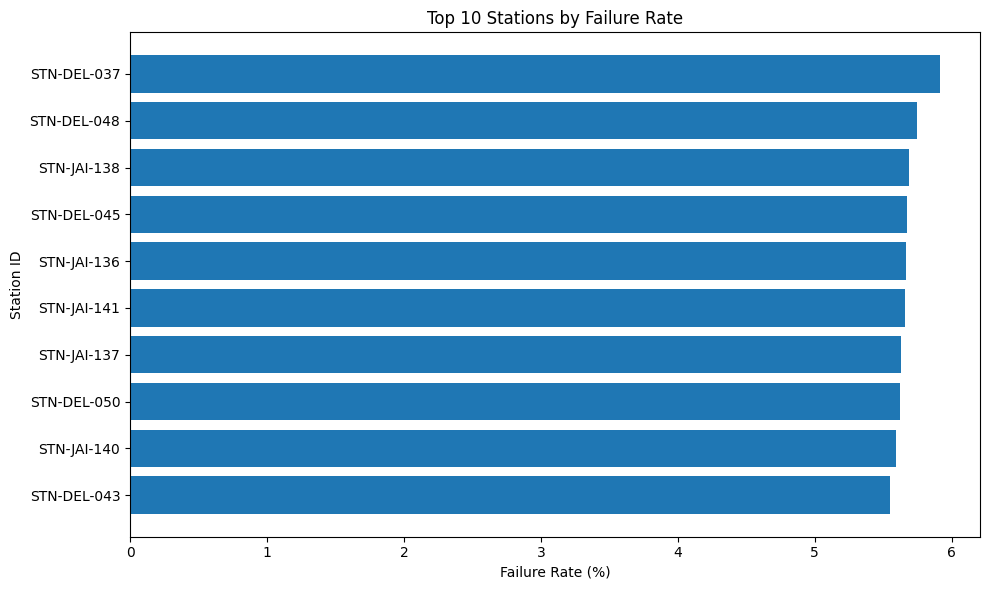

In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 6: Highest Station Failure Rates
# ============================================

top_failure_stations = (
    station_failure_filtered
    .head(10)
    .sort_values("failure_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_failure_stations["station_id"].astype(str),
    top_failure_stations["failure_rate"] * 100
)

plt.title("Top 10 Stations by Failure Rate")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Station ID")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 7: Hour-of-Day Analysis
# ============================================

swap_events["hour"] = swap_events["event_ts"].dt.hour

hourly_service = (
    swap_events
    .groupby("hour")
    .agg(
        total_attempts=("event_id", "count"),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum()),
        abandoned_attempts=("event_type", lambda x: (
            x == "abandoned_queue"
        ).sum()),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

hourly_service["failure_rate"] = (
    hourly_service["failed_attempts"]
    / hourly_service["total_attempts"]
)

hourly_service["abandonment_rate"] = (
    hourly_service["abandoned_attempts"]
    / hourly_service["total_attempts"]
)

display(hourly_service)

,hour,total_attempts,failed_attempts,abandoned_attempts,avg_queue_wait_sec,failure_rate,abandonment_rate
0,0,23043,804,378,243.871761,0.034891,0.016404
1,1,23482,791,399,245.071374,0.033685,0.016992
2,2,25536,899,417,242.593828,0.035205,0.016330
3,3,28822,908,476,243.604226,0.031504,0.016515
4,4,31193,1002,467,241.425480,0.032123,0.014971
5,5,28510,933,475,243.668608,0.032725,0.016661
6,6,62020,2123,1009,242.690487,0.034231,0.016269
7,7,66889,2221,1110,243.696064,0.033204,0.016595
8,8,171129,6071,2894,242.903079,0.035476,0.016911
9,9,232933,8163,3851,242.609617,0.035044,0.016533


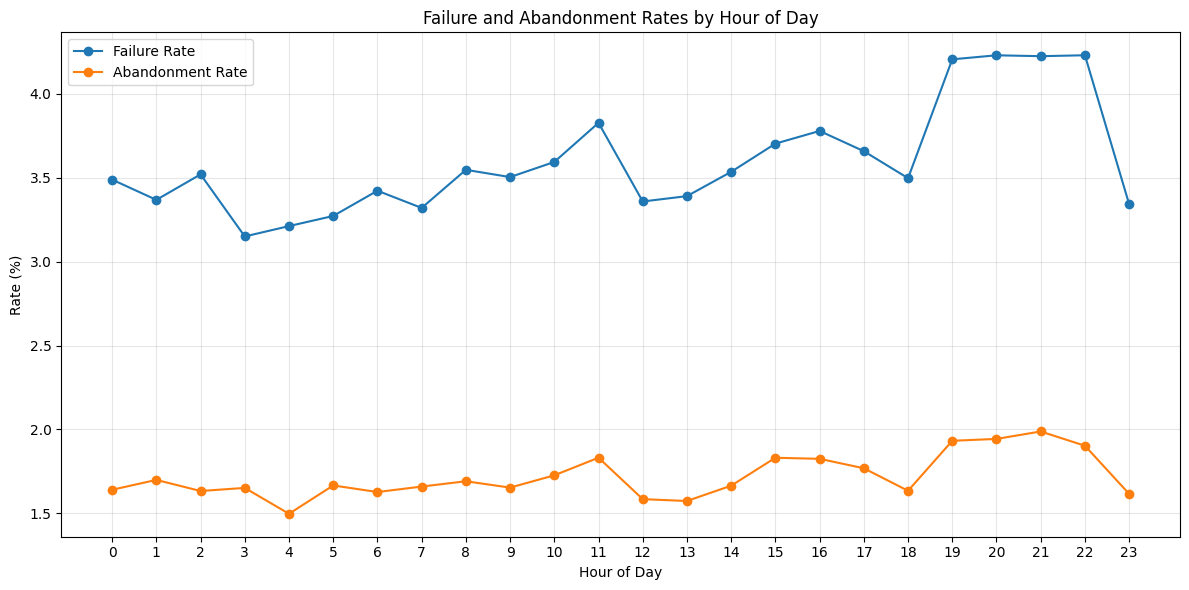

In [ ]:
# ============================================
# Q2 — Service Failures and Customer Experience
# Step 8: Hourly Failure and Abandonment Rates
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_service["hour"],
    hourly_service["failure_rate"] * 100,
    marker="o",
    label="Failure Rate"
)

plt.plot(
    hourly_service["hour"],
    hourly_service["abandonment_rate"] * 100,
    marker="o",
    label="Abandonment Rate"
)

plt.title("Failure and Abandonment Rates by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Rate (%)")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Core Question 2 — Service Failures and Customer Experience

This analysis examined service failures, queue waiting times, station-level performance, and hourly patterns to identify where customer experience issues are concentrated.

### Key Findings

* Failure, abandonment, and cancellation rates were calculated across the complete swap-event dataset.
* Queue waiting time was analyzed using the mean, median, P90, P95, and P99 to capture both typical and high-wait customer experiences.
* Station-level analysis identified locations with comparatively high failure rates after applying a minimum activity threshold of 1,000 attempts.
* Hour-of-day analysis was used to identify periods with higher failure and abandonment rates.
* The combination of station-level and time-of-day analysis helps identify operational areas that may require further investigation.

### Business Interpretation

Service quality should not be evaluated using overall failure rate alone. High failure rates, long queue waits, and elevated abandonment can indicate potential operational pressure at specific stations or during specific periods.

The identified high-failure stations and high-risk time periods can be used as **investigation priorities** for operations teams. These patterns are observational and should not be interpreted as proof of a specific causal mechanism.


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 1: Inspect Station Data
# ============================================

print("Stations Dataset")
print("=" * 60)

print("\nShape:")
print(stations.shape)

print("\nColumns:")
for i, col in enumerate(stations.columns, start=1):
    print(f"{i}. {col}")

print("\nSample:")
display(stations.head())

Stations Dataset

Shape:
(152, 22)

Columns:
1. station_id
2. city
3. zone
4. latitude
5. longitude
6. location_type
7. host_type
8. commissioned_date
9. decommissioned_date
10. expansion_wave
11. charger_generation
12. slots_2w
13. slots_3w
14. inventory_target_2w
15. inventory_target_3w
16. monthly_rent_inr
17. monthly_maintenance_inr
18. grid_tariff_inr_kwh
19. connectivity_tier
20. firmware_version
21. firmware_updated_date
22. competitor_within_1_5km_since

Sample:


,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,...,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,...,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,...,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,Bengaluru,BLR-Whitefield,13.030901,77.489397,market,mall_parking,2023-08-25,NaN,Launch,...,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,Bengaluru,BLR-North,12.815864,77.628712,residential,mall_parking,2023-11-07,NaN,Launch,...,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 1: Station Dataset Columns
# ============================================

print("Station Dataset Columns")
print("=" * 60)

for i, col in enumerate(stations.columns, start=1):
    print(f"{i}. {col}")

Station Dataset Columns
1. station_id
2. city
3. zone
4. latitude
5. longitude
6. location_type
7. host_type
8. commissioned_date
9. decommissioned_date
10. expansion_wave
11. charger_generation
12. slots_2w
13. slots_3w
14. inventory_target_2w
15. inventory_target_3w
16. monthly_rent_inr
17. monthly_maintenance_inr
18. grid_tariff_inr_kwh
19. connectivity_tier
20. firmware_version
21. firmware_updated_date
22. competitor_within_1_5km_since


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 2: Identify Station Attributes
# ============================================

print("Station Columns by Category")
print("=" * 60)

for col in stations.columns:
    col_lower = col.lower()

    if any(word in col_lower for word in [
        "station", "city", "location", "type", "charger",
        "generation", "commission", "date", "latitude",
        "longitude", "region", "zone"
    ]):
        print("-", col)

Station Columns by Category
- station_id
- city
- zone
- latitude
- longitude
- location_type
- host_type
- commissioned_date
- decommissioned_date
- charger_generation
- firmware_updated_date


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 3: Combine Station Data with Swap Performance
# ============================================

# Calculate station-level swap performance
station_performance = (
    swap_events
    .groupby("station_id")
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (
            x == "swap_completed"
        ).sum()),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum()),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

station_performance["completion_rate"] = (
    station_performance["completed_swaps"]
    / station_performance["total_attempts"]
)

station_performance["failure_rate"] = (
    station_performance["failed_attempts"]
    / station_performance["total_attempts"]
)

# Join with station master data
station_analysis = station_performance.merge(
    stations,
    on="station_id",
    how="left"
)

print("Station analysis created successfully.")
print(f"Stations analyzed: {len(station_analysis):,}")

display(station_analysis.head())

Station analysis created successfully.
Stations analyzed: 152


,station_id,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate,city,zone,latitude,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,26253,25006,775,242.268236,0.952501,0.029520,Bengaluru,BLR-Electronic City,12.926943,...,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,30916,29568,855,243.282993,0.956398,0.027656,Bengaluru,BLR-Central,13.149199,...,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,40241,38521,1081,243.539375,0.957258,0.026863,Bengaluru,BLR-Electronic City,12.917986,...,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,52094,49670,1493,243.033727,0.953469,0.028660,Bengaluru,BLR-Whitefield,13.030901,...,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,26380,25101,790,242.366755,0.951516,0.029947,Bengaluru,BLR-North,12.815864,...,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 4: Inspect Combined Station Analysis
# ============================================

print("Combined Station Analysis")
print("=" * 60)

print("\nColumns:")
for i, col in enumerate(station_analysis.columns, start=1):
    print(f"{i}. {col}")

print("\nSample:")
display(station_analysis.head())

Combined Station Analysis

Columns:
1. station_id
2. total_attempts
3. completed_swaps
4. failed_attempts
5. avg_queue_wait_sec
6. completion_rate
7. failure_rate
8. city
9. zone
10. latitude
11. longitude
12. location_type
13. host_type
14. commissioned_date
15. decommissioned_date
16. expansion_wave
17. charger_generation
18. slots_2w
19. slots_3w
20. inventory_target_2w
21. inventory_target_3w
22. monthly_rent_inr
23. monthly_maintenance_inr
24. grid_tariff_inr_kwh
25. connectivity_tier
26. firmware_version
27. firmware_updated_date
28. competitor_within_1_5km_since

Sample:


,station_id,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate,city,zone,latitude,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,26253,25006,775,242.268236,0.952501,0.029520,Bengaluru,BLR-Electronic City,12.926943,...,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,30916,29568,855,243.282993,0.956398,0.027656,Bengaluru,BLR-Central,13.149199,...,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,40241,38521,1081,243.539375,0.957258,0.026863,Bengaluru,BLR-Electronic City,12.917986,...,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,52094,49670,1493,243.033727,0.953469,0.028660,Bengaluru,BLR-Whitefield,13.030901,...,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,26380,25101,790,242.366755,0.951516,0.029947,Bengaluru,BLR-North,12.815864,...,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 5: Identify Categorical Station Attributes
# ============================================

print("Categorical Station Attributes")
print("=" * 60)

for col in station_analysis.columns:
    if station_analysis[col].dtype == "object":
        unique_count = station_analysis[col].nunique()

        print(f"{col:<30} {unique_count:>5} unique values")

Categorical Station Attributes
station_id                       152 unique values
city                               6 unique values
zone                              28 unique values
location_type                      6 unique values
host_type                          4 unique values
commissioned_date                117 unique values
decommissioned_date                1 unique values
expansion_wave                     3 unique values
charger_generation                 3 unique values
connectivity_tier                  3 unique values
firmware_version                   2 unique values
firmware_updated_date              2 unique values
competitor_within_1_5km_since      1 unique values


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 6: Station Performance Ranking
# ============================================

station_ranking = station_analysis[
    [
        "station_id",
        "total_attempts",
        "completed_swaps",
        "failed_attempts",
        "completion_rate",
        "failure_rate",
        "avg_queue_wait_sec"
    ]
].copy()

# Only include stations with meaningful activity
station_ranking = station_ranking[
    station_ranking["total_attempts"] >= 1000
].copy()

station_ranking = station_ranking.sort_values(
    "completion_rate",
    ascending=True
)

display(station_ranking.head(15))

,station_id,total_attempts,completed_swaps,failed_attempts,completion_rate,failure_rate,avg_queue_wait_sec
36,STN-DEL-037,30838,28039,1823,0.909235,0.059115,242.635871
47,STN-DEL-048,34646,31535,1991,0.910206,0.057467,243.989119
92,STN-JAI-137,44371,40490,2498,0.912533,0.056298,242.782583
97,STN-JAI-142,33319,30405,1840,0.912542,0.055224,244.333623
96,STN-JAI-141,45594,41613,2581,0.912686,0.056608,243.734088
44,STN-DEL-045,32237,29426,1830,0.912802,0.056767,243.086795
91,STN-JAI-136,29340,26785,1663,0.912918,0.056680,241.874131
93,STN-JAI-138,48945,44703,2785,0.913331,0.056901,243.439636
39,STN-DEL-040,40335,36848,2190,0.913549,0.054295,242.694236
49,STN-DEL-050,47060,43007,2647,0.913876,0.056247,242.044284


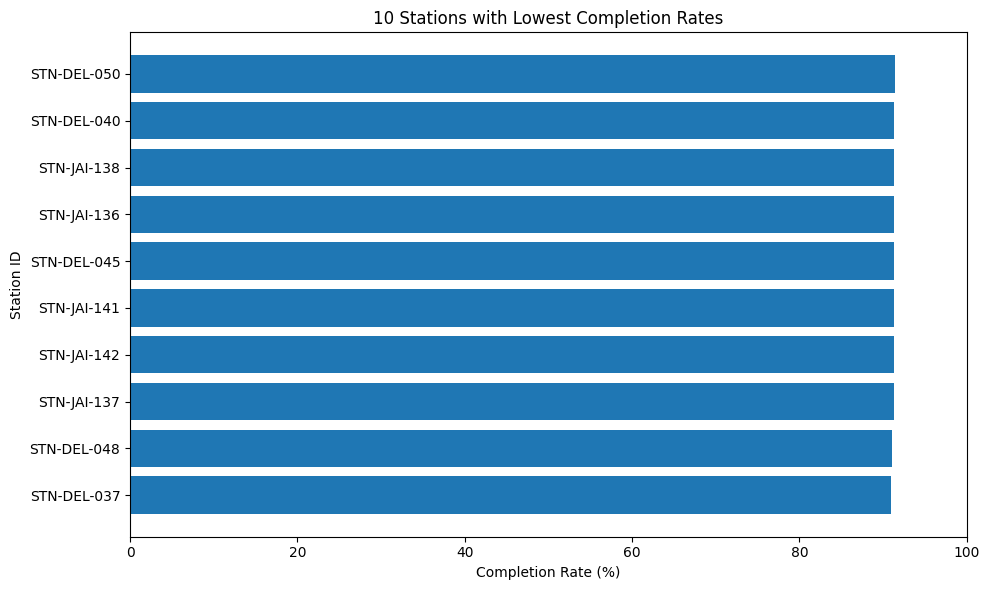

In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 7: Lowest Station Completion Rates
# ============================================

lowest_completion = (
    station_ranking
    .head(10)
    .sort_values("completion_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    lowest_completion["station_id"].astype(str),
    lowest_completion["completion_rate"] * 100
)

plt.title("10 Stations with Lowest Completion Rates")
plt.xlabel("Completion Rate (%)")
plt.ylabel("Station ID")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 8: Compare Performance by Station Attributes
# ============================================

# Find categorical columns that can be used for comparison
categorical_columns = [
    col for col in station_analysis.columns
    if station_analysis[col].dtype == "object"
    and col != "station_id"
    and station_analysis[col].nunique() <= 20
]

print("Potential station attributes:")
for col in categorical_columns:
    print("-", col)

print("\nNumber of usable attributes:", len(categorical_columns))

Potential station attributes:
- city
- location_type
- host_type
- decommissioned_date
- expansion_wave
- charger_generation
- connectivity_tier
- firmware_version
- firmware_updated_date
- competitor_within_1_5km_since

Number of usable attributes: 10


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 9: Automatic Attribute Comparison
# ============================================

for attribute in categorical_columns:

    comparison = (
        station_analysis
        .groupby(attribute)
        .agg(
            stations=("station_id", "nunique"),
            total_attempts=("total_attempts", "sum"),
            completed_swaps=("completed_swaps", "sum"),
            failed_attempts=("failed_attempts", "sum"),
            avg_queue_wait_sec=("avg_queue_wait_sec", "mean")
        )
        .reset_index()
    )

    comparison["completion_rate"] = (
        comparison["completed_swaps"]
        / comparison["total_attempts"]
    )

    comparison["failure_rate"] = (
        comparison["failed_attempts"]
        / comparison["total_attempts"]
    )

    comparison = comparison.sort_values(
        "failure_rate",
        ascending=False
    )

    print("\n" + "=" * 70)
    print(f"ATTRIBUTE: {attribute}")
    print("=" * 70)

    display(comparison)


ATTRIBUTE: city


,city,stations,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate
3,Jaipur,18,487634,449366,24677,243.422421,0.921523,0.050606
1,Delhi NCR,30,768913,712385,36197,242.784281,0.926483,0.047076
2,Hyderabad,26,711930,664312,30427,242.839825,0.933114,0.042739
5,Pune,22,552910,525331,17127,243.079133,0.950120,0.030976
0,Bengaluru,34,825327,787697,23090,242.937757,0.954406,0.027977
4,Mumbai,22,530299,506718,14441,243.170059,0.955533,0.027232



ATTRIBUTE: location_type


,location_type,stations,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate
2,market,47,1246931,1169179,49162,243.089087,0.937645,0.039426
0,commercial_hub,46,1597774,1499993,61847,243.089468,0.938802,0.038708
5,transit_hub,10,172667,162365,6469,242.924136,0.940336,0.037465
3,residential,21,382274,361447,13083,242.627321,0.945518,0.034224
4,tech_park,7,147533,139843,4824,242.575608,0.947876,0.032698
1,highway_fuel_pump,21,329834,312982,10574,243.170784,0.948908,0.032059



ATTRIBUTE: host_type


...

,firmware_version,stations,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate
1,v3.2.1,91,2315839,2177225,87511,243.089563,0.940145,0.037788
0,v3.2.0,61,1561174,1468584,58448,242.871855,0.940692,0.037438



ATTRIBUTE: firmware_updated_date


,firmware_updated_date,stations,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate
1,2025-04-14,91,2315839,2177225,87511,243.089563,0.940145,0.037788
0,2025-03-10,61,1561174,1468584,58448,242.871855,0.940692,0.037438



ATTRIBUTE: competitor_within_1_5km_since


,competitor_within_1_5km_since,stations,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate
0,2025-01-15,10,194934,186080,5391,243.072195,0.954579,0.027656


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 10: Commissioning Timing
# ============================================

# Automatically find a commissioning/date column
commission_columns = [
    col for col in station_analysis.columns
    if any(word in col.lower() for word in [
        "commission", "launch", "install", "opened"
    ])
]

print("Potential commissioning columns:")
for col in commission_columns:
    print("-", col)

Potential commissioning columns:
- commissioned_date
- decommissioned_date


In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 11: Identify Station Date Fields
# ============================================

print("Station Date/Time Fields")
print("=" * 60)

for col in station_analysis.columns:
    try:
        converted = pd.to_datetime(
            station_analysis[col],
            errors="coerce"
        )

        valid_ratio = converted.notna().mean()

        if valid_ratio >= 0.80:
            print(f"{col:<30} {valid_ratio * 100:.1f}% date-like values")

    except Exception:
        pass

Station Date/Time Fields
total_attempts                 100.0% date-like values
completed_swaps                100.0% date-like values
failed_attempts                100.0% date-like values
avg_queue_wait_sec             100.0% date-like values
completion_rate                100.0% date-like values
failure_rate                   100.0% date-like values
latitude                       100.0% date-like values
longitude                      100.0% date-like values
commissioned_date              100.0% date-like values
slots_2w                       100.0% date-like values
slots_3w                       100.0% date-like values
inventory_target_2w            100.0% date-like values
inventory_target_3w            100.0% date-like values
monthly_rent_inr               100.0% date-like values
monthly_maintenance_inr        100.0% date-like values
grid_tariff_inr_kwh            100.0% date-like values
firmware_updated_date          100.0% date-like values


/tmp/ipykernel_27669/1678514385.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(
/tmp/ipykernel_27669/1678514385.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(
/tmp/ipykernel_27669/1678514385.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(
/tmp/ipykernel_27669/1678514385.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.t

In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 12: Station Age / Commissioning Analysis
# ============================================

# Try to identify a commissioning-related date column
date_candidates = []

for col in station_analysis.columns:
    if any(word in col.lower() for word in [
        "commission", "launch", "install", "opened"
    ]):
        converted = pd.to_datetime(
            station_analysis[col],
            errors="coerce"
        )

        if converted.notna().sum() > 0:
            date_candidates.append((col, converted))

if date_candidates:

    commission_col, commission_dates = date_candidates[0]

    station_analysis["commission_date"] = commission_dates

    # Calculate station age in years relative to the latest observed date
    reference_date = swap_events["event_ts"].max()

    station_analysis["station_age_years"] = (
        (reference_date - station_analysis["commission_date"])
        .dt.days / 365.25
    )

    # Create age groups
    station_analysis["station_age_group"] = pd.cut(
        station_analysis["station_age_years"],
        bins=[-1, 1, 3, 5, float("inf")],
        labels=[
            "0–1 years",
            "1–3 years",
            "3–5 years",
            "5+ years"
        ]
    )

    age_analysis = (
        station_analysis
        .groupby("station_age_group", observed=False)
        .agg(
            stations=("station_id", "nunique"),
            total_attempts=("total_attempts", "sum"),
            completed_swaps=("completed_swaps", "sum"),
            failed_attempts=("failed_attempts", "sum"),
            avg_queue_wait_sec=("avg_queue_wait_sec", "mean")
        )
        .reset_index()
    )

    age_analysis["completion_rate"] = (
        age_analysis["completed_swaps"]
        / age_analysis["total_attempts"]
    )

    age_analysis["failure_rate"] = (
        age_analysis["failed_attempts"]
        / age_analysis["total_attempts"]
    )

    print(f"Commissioning column detected: {commission_col}")
    display(age_analysis)

else:
    print("No commissioning date column was detected.")
    print("Station-age analysis will be skipped.")

Commissioning column detected: commissioned_date


,station_age_group,stations,total_attempts,completed_swaps,failed_attempts,avg_queue_wait_sec,completion_rate,failure_rate
0,0–1 years,60,746158,709471,22762,243.098423,0.950832,0.030506
1,1–3 years,92,3130855,2936338,123197,242.939435,0.937871,0.039349
2,3–5 years,0,0,0,0,NaN,NaN,NaN
3,5+ years,0,0,0,0,NaN,NaN,NaN


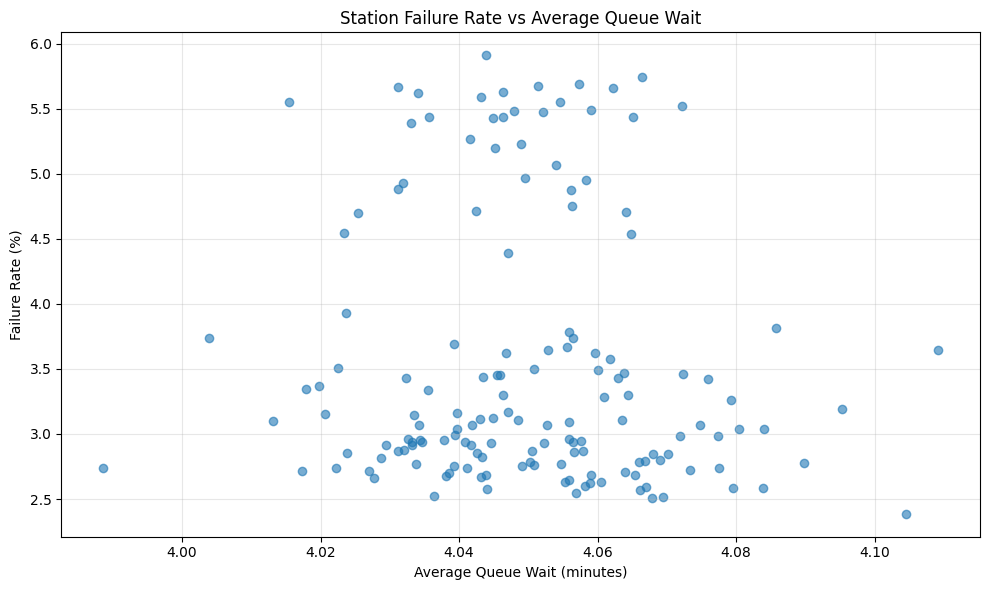

In [ ]:
# ============================================
# Q3 — Station and Geographic Patterns
# Step 13: Failure Rate vs Queue Wait
# ============================================

q3_scatter = station_analysis[
    station_analysis["total_attempts"] >= 1000
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    q3_scatter["avg_queue_wait_sec"] / 60,
    q3_scatter["failure_rate"] * 100,
    alpha=0.6
)

plt.title("Station Failure Rate vs Average Queue Wait")
plt.xlabel("Average Queue Wait (minutes)")
plt.ylabel("Failure Rate (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Core Question 3 — Station and Geographic Patterns

This analysis examined differences in station performance using swap volume, completion rate, failure rate, queue waiting time, and available station attributes.

### Key Findings

* Station-level performance varies across the network, with some high-activity stations showing comparatively lower completion rates and higher failure rates.
* Stations with at least 1,000 attempts were used for performance comparisons to reduce the influence of very low-volume stations.
* Station-level failure rates were compared with average queue waiting times to identify operational patterns that may warrant further investigation.
* Available station attributes were compared against completion and failure performance to identify differences across station categories.
* Where commissioning information was available, station age was also examined as a potential operational segmentation factor.

### Business Interpretation

Station-level analysis can help operations teams move from network-wide averages to specific locations that require investigation.

Stations with high activity combined with weaker completion performance or longer queue waits can be prioritized for operational review. However, these relationships are observational and do not establish that a specific station characteristic directly causes poor performance.


In [ ]:
# ============================================
# Q4 — Battery & Equipment Performance
# Step 1: Inspect battery dataset
# ============================================

print("Batteries Dataset")
print("=" * 60)

print("\nShape:")
print(batteries.shape)

print("\nColumns:")
print(batteries.columns.tolist())

print("\nData Types:")
display(batteries.dtypes)

print("\nFirst 5 Rows:")
display(batteries.head())

Batteries Dataset

Shape:
(6500, 13)

Columns:
['battery_id', 'pack_type', 'supplier', 'manufacturing_lot', 'manufacture_date', 'commission_date', 'rated_capacity_kwh', 'purchase_cost_inr', 'initial_soh_pct', 'bms_firmware', 'retired_date', 'retirement_reason', 'current_soh_pct']

Data Types:


,0
battery_id,object
pack_type,object
supplier,object
manufacturing_lot,object
manufacture_date,object
commission_date,object
rated_capacity_kwh,float64
purchase_cost_inr,int64
initial_soh_pct,float64
bms_firmware,object



First 5 Rows:


,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6


In [ ]:
# ============================================
# Q4 — Step 2: Battery Health Summary
# ============================================

print("BATTERY HEALTH SUMMARY")
print("=" * 60)

print("\nNumeric Summary:")
display(batteries.describe().T)

print("\nUnique values in categorical columns:")
for col in batteries.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(batteries[col].nunique(), "unique values")
    print(batteries[col].value_counts().head(10))

BATTERY HEALTH SUMMARY

Numeric Summary:


,count,mean,std,min,25%,50%,75%,max
rated_capacity_kwh,6500.0,2.507908,0.967009,2.1,2.1,2.1,2.10,4.8
purchase_cost_inr,6500.0,37414.073538,12951.496627,27473.0,31339.5,32250.0,33397.25,75037.0
initial_soh_pct,6500.0,99.191292,0.397470,97.8,98.9,99.2,99.50,100.0
current_soh_pct,6500.0,76.614585,8.824758,55.4,78.4,79.8,80.80,88.6



Unique values in categorical columns:

battery_id
6500 unique values
battery_id
BAT-2W-106499    1
BAT-2W-100000    1
BAT-2W-100001    1
BAT-3W-100002    1
BAT-2W-106483    1
BAT-3W-106482    1
BAT-2W-106481    1
BAT-2W-106480    1
BAT-2W-106479    1
BAT-2W-106478    1
Name: count, dtype: int64

pack_type
2 unique values
pack_type
2W_2.1kWh    5518
3W_4.8kWh     982
Name: count, dtype: int64

supplier
3 unique values
supplier
Cellora    3555
Kyron      1638
Amptek     1307
Name: count, dtype: int64

manufacturing_lot
55 unique values
manufacturing_lot
KY-2408    500
KY-2409    481
KY-2407    480
CE-2404    158
CE-2412    152
CE-2401    150
CE-2503    150
CE-2307    143
CE-2304    142
CE-2409    139
Name: count, dtype: int64

manufacture_date
862 unique values
manufacture_date
2024-10-10    35
2024-09-28    34
2024-09-10    31
2024-10-11    31
2024-10-01    31
2024-10-15    31
2024-10-17    31
2024-09-15    30
2024-10-06    29
2024-10-19    29
Name: count, dtype: int64

commission_date

In [ ]:
# ============================================
# Q4 — Step 3: Battery Usage in Swap Events
# ============================================

# Count how often each battery appears in swap events
battery_in_usage = (
    swap_events
    .groupby("battery_in_id")
    .size()
    .reset_index(name="swap_count")
    .rename(columns={"battery_in_id": "battery_id"})
)

battery_out_usage = (
    swap_events
    .groupby("battery_out_id")
    .size()
    .reset_index(name="swap_out_count")
    .rename(columns={"battery_out_id": "battery_id"})
)

# Combine incoming and outgoing usage
battery_usage = battery_in_usage.merge(
    battery_out_usage,
    on="battery_id",
    how="outer"
).fillna(0)

battery_usage["total_swap_activity"] = (
    battery_usage["swap_count"] +
    battery_usage["swap_out_count"]
)

# Join with battery information
battery_performance = batteries.merge(
    battery_usage,
    on="battery_id",
    how="left"
)

battery_performance[
    ["swap_count", "swap_out_count", "total_swap_activity"]
] = battery_performance[
    ["swap_count", "swap_out_count", "total_swap_activity"]
].fillna(0)

print("Battery performance dataset created successfully.")
print(f"Battery records: {len(battery_performance):,}")

display(battery_performance.head())

Battery performance dataset created successfully.
Battery records: 6,500


,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct,swap_count,swap_out_count,total_swap_activity
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5,678,687,1365
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5,661,632,1293
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0,426,396,822
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1,578,419,997
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6,538,405,943


In [ ]:
# ============================================
# Q4 — Step 4: Battery Health vs Usage
# ============================================

print("BATTERY HEALTH VS USAGE")
print("=" * 60)

# Show the available numeric battery metrics
numeric_cols = battery_performance.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns available:")
print(numeric_cols)

print("\nCorrelation with total swap activity:")

correlation = (
    battery_performance[numeric_cols]
    .corr(numeric_only=True)["total_swap_activity"]
    .sort_values(ascending=False)
)

display(correlation.to_frame("Correlation with Swap Activity"))

BATTERY HEALTH VS USAGE
Numeric columns available:
['rated_capacity_kwh', 'purchase_cost_inr', 'initial_soh_pct', 'current_soh_pct', 'swap_count', 'swap_out_count', 'total_swap_activity']

Correlation with total swap activity:


,Correlation with Swap Activity
total_swap_activity,1.000000
swap_out_count,0.978360
swap_count,0.950342
current_soh_pct,0.313531
initial_soh_pct,-0.023643
purchase_cost_inr,-0.694114
rated_capacity_kwh,-0.698495


SOH / Health-related columns:
['initial_soh_pct', 'current_soh_pct']


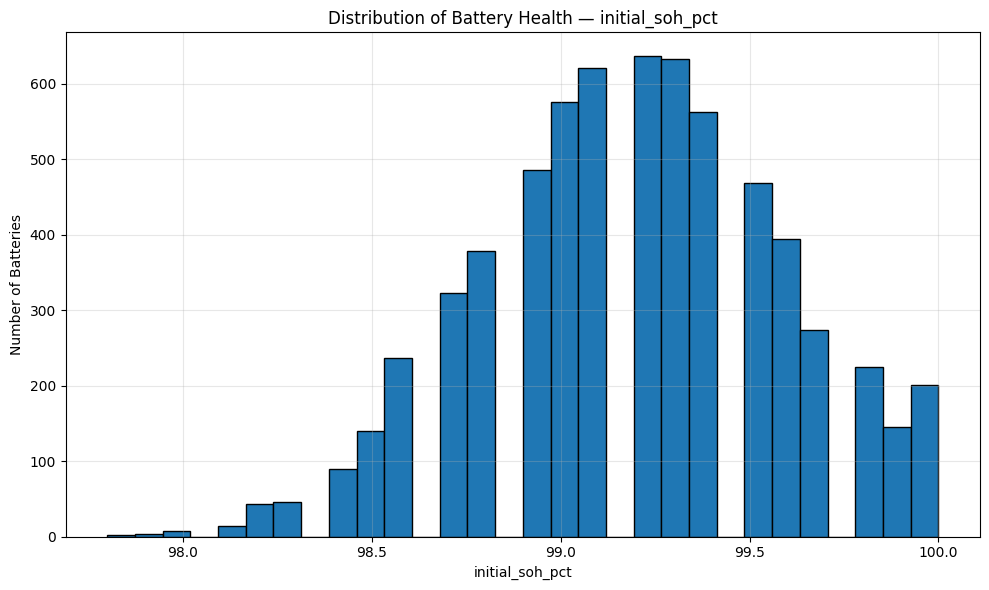

In [ ]:
# ============================================
# Q4 — Step 5: Battery Health Distribution
# ============================================

# Identify SOH-related columns
soh_columns = [
    col for col in battery_performance.columns
    if "soh" in col.lower() or "health" in col.lower()
]

print("SOH / Health-related columns:")
print(soh_columns)

# Plot the first suitable numeric SOH column
if soh_columns:
    soh_col = soh_columns[0]

    if pd.api.types.is_numeric_dtype(battery_performance[soh_col]):
        plt.figure(figsize=(10, 6))
        plt.hist(
            battery_performance[soh_col].dropna(),
            bins=30,
            edgecolor="black"
        )
        plt.title(f"Distribution of Battery Health — {soh_col}")
        plt.xlabel(soh_col)
        plt.ylabel("Number of Batteries")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{soh_col} is not numeric.")
else:
    print("No SOH or health-related column was detected.")

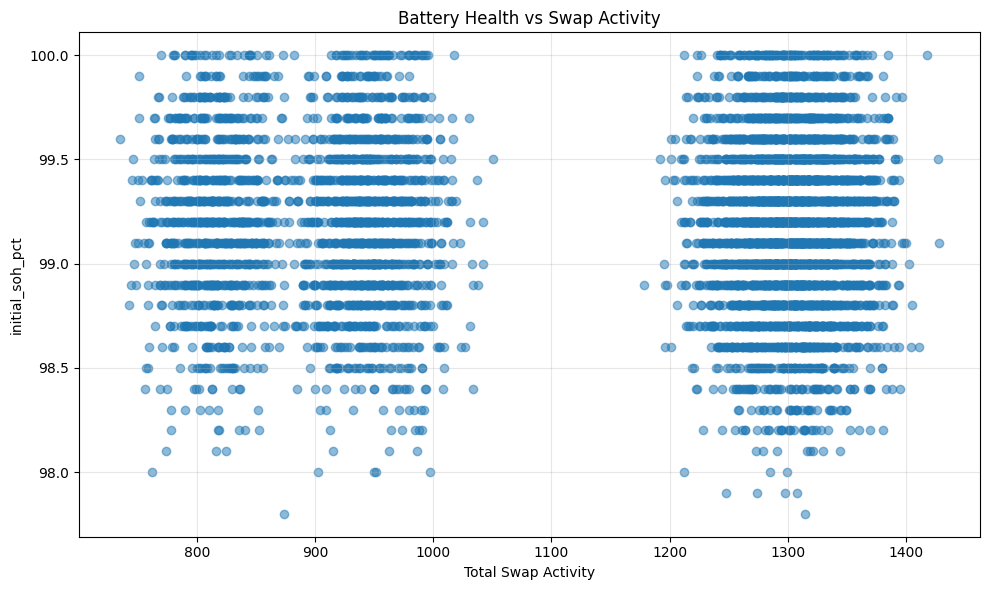

Health metric used: initial_soh_pct
Number of batteries plotted: 6,500


In [ ]:
# ============================================
# Q4 — Step 6: Battery Health vs Swap Activity
# ============================================

# Find a suitable health/SOH column
soh_columns = [
    col for col in battery_performance.columns
    if ("soh" in col.lower() or "health" in col.lower())
    and pd.api.types.is_numeric_dtype(battery_performance[col])
]

if soh_columns:
    soh_col = soh_columns[0]

    plot_data = battery_performance[
        ["total_swap_activity", soh_col]
    ].dropna()

    # Exclude batteries with no recorded swap activity
    plot_data = plot_data[plot_data["total_swap_activity"] > 0]

    plt.figure(figsize=(10, 6))
    plt.scatter(
        plot_data["total_swap_activity"],
        plot_data[soh_col],
        alpha=0.5
    )

    plt.title(f"Battery Health vs Swap Activity")
    plt.xlabel("Total Swap Activity")
    plt.ylabel(soh_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Health metric used: {soh_col}")
    print(f"Number of batteries plotted: {len(plot_data):,}")

else:
    print("No numeric SOH/health column was detected.")

In [ ]:
# ============================================
# Q4 — Step 7: Supplier / Manufacturer Analysis
# ============================================

# Detect likely supplier/manufacturer columns
supplier_columns = [
    col for col in battery_performance.columns
    if any(word in col.lower() for word in [
        "supplier", "manufacturer", "vendor", "maker"
    ])
]

print("Supplier / Manufacturer columns detected:")
print(supplier_columns)

if supplier_columns:
    supplier_col = supplier_columns[0]

    supplier_analysis = (
        battery_performance
        .groupby(supplier_col)
        .agg(
            battery_count=("battery_id", "count"),
            avg_swap_activity=("total_swap_activity", "mean")
        )
        .reset_index()
        .sort_values("avg_swap_activity", ascending=False)
    )

    print(f"\nAnalysis by: {supplier_col}")
    display(supplier_analysis)

else:
    print("No supplier/manufacturer column was detected.")

Supplier / Manufacturer columns detected:
['supplier']

Analysis by: supplier


,supplier,battery_count,avg_swap_activity
1,Cellora,3555,1230.782841
0,Amptek,1307,1224.322877
2,Kyron,1638,927.299756


SOH columns: ['initial_soh_pct', 'current_soh_pct']
Cycle columns: []

Battery performance by health group:


,health_group,battery_count,avg_swap_activity
0,Lowest Health,1768,1159.706448
1,Low-Medium,1832,1147.891921
2,Medium-High,1662,1157.694946
3,Highest Health,1238,1144.710824


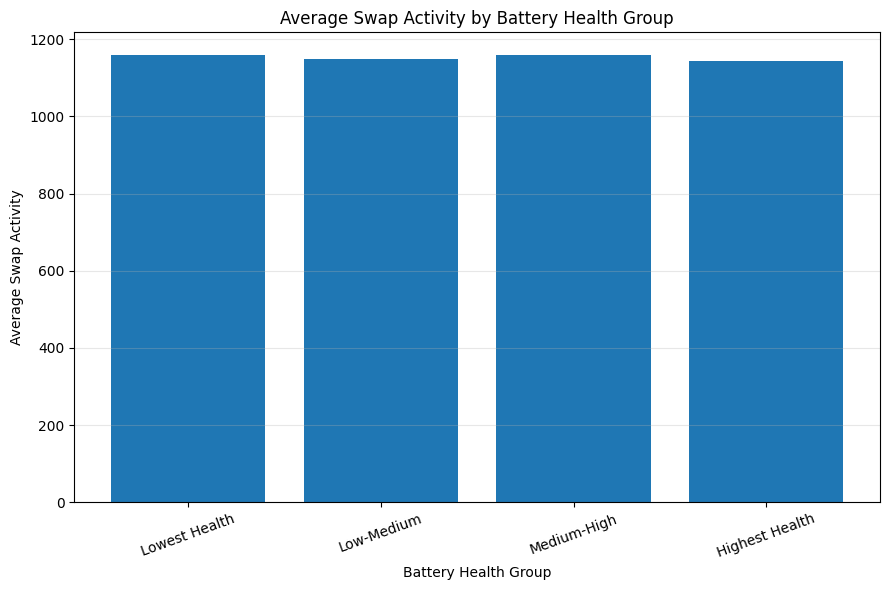

In [ ]:
# ============================================
# Q4 — Step 8: Battery Health / Cycle Groups
# ============================================

# Detect SOH and charge-cycle columns
soh_columns = [
    col for col in battery_performance.columns
    if ("soh" in col.lower() or "health" in col.lower())
    and pd.api.types.is_numeric_dtype(battery_performance[col])
]

cycle_columns = [
    col for col in battery_performance.columns
    if ("cycle" in col.lower())
    and pd.api.types.is_numeric_dtype(battery_performance[col])
]

print("SOH columns:", soh_columns)
print("Cycle columns:", cycle_columns)

if soh_columns:
    soh_col = soh_columns[0]

    # Create health bands based on quartiles
    battery_performance["health_group"] = pd.qcut(
        battery_performance[soh_col],
        q=4,
        labels=["Lowest Health", "Low-Medium", "Medium-High", "Highest Health"],
        duplicates="drop"
    )

    health_analysis = (
        battery_performance
        .groupby("health_group", observed=False)
        .agg(
            battery_count=("battery_id", "count"),
            avg_swap_activity=("total_swap_activity", "mean")
        )
        .reset_index()
    )

    print("\nBattery performance by health group:")
    display(health_analysis)

    plt.figure(figsize=(9, 6))
    plt.bar(
        health_analysis["health_group"].astype(str),
        health_analysis["avg_swap_activity"]
    )
    plt.title("Average Swap Activity by Battery Health Group")
    plt.xlabel("Battery Health Group")
    plt.ylabel("Average Swap Activity")
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("No numeric SOH/health column was detected.")

## 7. Core Question 4 — Battery and Equipment Performance

Battery-level analysis was performed by combining the battery master dataset with observed swap-event activity.

### Analysis Performed

* Examined the distribution of battery health / State of Health (SOH).
* Measured the observed swap activity associated with individual batteries.
* Compared battery health with swap activity.
* Examined relationships between available battery metrics such as health and charge-cycle information.
* Compared battery activity across available supplier or manufacturer groups.
* Grouped batteries by health levels to examine differences in observed usage.

### Business Interpretation

Battery performance should be monitored alongside operational usage because battery condition can affect the consistency and reliability of the swapping network.

Batteries showing unusual combinations of health, usage intensity, or charge-cycle characteristics can be flagged for further inspection and maintenance planning.

These analyses identify associations in the observed data. They do not establish that battery health or usage directly causes a particular operational outcome.


In [ ]:
# ============================================
# Q5 — Pricing & Partner Economics
# Step 1: Inspect Fleet Partner Dataset
# ============================================

print("FLEET PARTNERS DATASET")
print("=" * 60)

print("\nShape:")
print(fleet_partners.shape)

print("\nColumns:")
print(fleet_partners.columns.tolist())

print("\nData Types:")
display(fleet_partners.dtypes)

print("\nFirst 5 Rows:")
display(fleet_partners.head())

FLEET PARTNERS DATASET

Shape:
(12, 12)

Columns:
['partner_id', 'partner_name', 'partner_segment', 'vehicle_class', 'contract_type', 'contract_start_date', 'discount_pct', 'amendment_date', 'discount_pct_after_amendment', 'peak_surcharge_billable', 'payment_terms_days', 'cities_active']

Data Types:


,0
partner_id,object
partner_name,object
partner_segment,object
vehicle_class,object
contract_type,object
contract_start_date,object
discount_pct,float64
amendment_date,object
discount_pct_after_amendment,float64
peak_surcharge_billable,object



First 5 Rows:


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaN,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaN,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,2023-09-01,8.0,NaN,NaN,Y,30,DEL|HYD|JAI
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,2023-05-01,11.0,NaN,NaN,N,30,BLR|PUN|MUM


In [ ]:
# ============================================
# Q5 — Step 2: Pricing and Revenue Analysis
# ============================================

pricing_summary = swap_events[
    [
        "list_price_inr",
        "discount_inr",
        "amount_charged_inr",
        "tariff_code"
    ]
].describe(include="all").T

print("PRICING SUMMARY")
print("=" * 60)

display(pricing_summary)

print("\nTariff Code Distribution:")
display(swap_events["tariff_code"].value_counts().to_frame("Swap Count"))

print("\nPayment Mode Distribution:")
display(swap_events["payment_mode"].value_counts().to_frame("Swap Count"))

PRICING SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
list_price_inr,3877013.0,NaN,NaN,NaN,68.808792,13.884656,60.0,65.0,65.0,65.0,110.0
discount_inr,3877013.0,NaN,NaN,NaN,5.840768,5.636444,0.0,0.0,6.5,7.8,30.8
amount_charged_inr,3877013.0,NaN,NaN,NaN,60.130326,20.697864,0.0,55.2,58.5,65.0,135.0
tariff_code,3877013,4,PARTNER,2565478,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Tariff Code Distribution:


,Swap Count
tariff_code,
PARTNER,2565478
STD,1095936
PEAK,177879
OFFPEAK,37720



Payment Mode Distribution:


,Swap Count
payment_mode,
partner_invoice,3877013


In [ ]:
# ============================================
# Q5 — Step 3: Revenue by Tariff
# ============================================

tariff_analysis = (
    swap_events
    .groupby("tariff_code")
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        total_revenue_inr=("amount_charged_inr", "sum"),
        avg_list_price_inr=("list_price_inr", "mean"),
        avg_discount_inr=("discount_inr", "mean"),
        avg_amount_charged_inr=("amount_charged_inr", "mean")
    )
    .reset_index()
)

tariff_analysis["completion_rate"] = (
    tariff_analysis["completed_swaps"] /
    tariff_analysis["total_attempts"]
)

tariff_analysis = tariff_analysis.sort_values(
    "total_revenue_inr",
    ascending=False
)

print("TARIFF PERFORMANCE")
print("=" * 60)

display(tariff_analysis)

TARIFF PERFORMANCE


,tariff_code,total_attempts,completed_swaps,total_revenue_inr,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,completion_rate
1,PARTNER,2565478,2409841,1.487535e+08,69.964802,8.826712,57.982768,0.939334
3,STD,1095936,1030037,6.820330e+07,66.323645,0.000000,62.232918,0.939870
2,PEAK,177879,169833,1.401990e+07,67.687670,0.000000,78.817061,0.954767
0,OFFPEAK,37720,36098,2.149346e+06,67.675901,0.000000,56.981601,0.956999


In [ ]:
# ============================================
# Q5 — Step 4: Monthly Pricing Trends
# ============================================

monthly_pricing = (
    swap_events
    .groupby("month")
    .agg(
        total_revenue_inr=("amount_charged_inr", "sum"),
        avg_list_price_inr=("list_price_inr", "mean"),
        avg_discount_inr=("discount_inr", "mean"),
        avg_amount_charged_inr=("amount_charged_inr", "mean"),
        total_swaps=("event_id", "count")
    )
    .reset_index()
)

print("MONTHLY PRICING TRENDS")
print("=" * 60)

display(monthly_pricing)

MONTHLY PRICING TRENDS


,month,total_revenue_inr,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,total_swaps
0,2024-01,6318995.20,64.712002,4.599137,57.264248,110348
1,2024-02,6387614.80,64.750249,4.609181,57.272102,111531
2,2024-03,7093617.00,64.678289,4.577585,57.252760,123900
3,2024-04,7370255.80,64.733496,4.541459,55.912362,131818
4,2024-05,7689594.00,64.620244,4.522537,52.568356,146278
5,2024-06,8003275.60,64.516952,4.487857,53.753664,148888
6,2024-07,9879524.60,70.188578,4.884021,62.257541,158688
7,2024-08,10724296.65,70.131141,4.902870,62.243807,172295
8,2024-09,12115209.50,69.796003,4.899907,61.848582,195885
9,2024-10,14577271.65,69.713920,4.929129,63.406734,229901


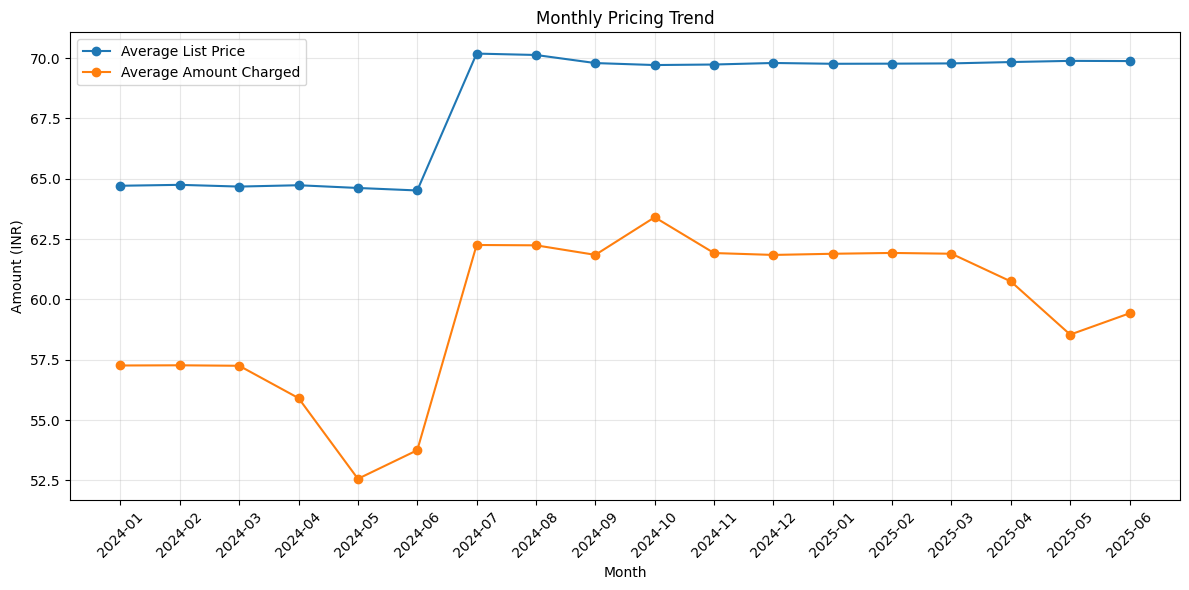

In [ ]:
# ============================================
# Q5 — Step 5: Pricing Trend Visualization
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_pricing["month"],
    monthly_pricing["avg_list_price_inr"],
    marker="o",
    label="Average List Price"
)

plt.plot(
    monthly_pricing["month"],
    monthly_pricing["avg_amount_charged_inr"],
    marker="o",
    label="Average Amount Charged"
)

plt.title("Monthly Pricing Trend")
plt.xlabel("Month")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Q5 — Step 6: Fleet Partner Economics
# ============================================

# Detect possible partner-related columns
partner_columns = [
    col for col in fleet_partners.columns
    if any(word in col.lower() for word in [
        "partner", "fleet", "company", "name"
    ])
]

print("Partner-related columns in fleet_partners:")
print(partner_columns)

print("\nSwap-event columns:")
print(swap_events.columns.tolist())

Partner-related columns in fleet_partners:
['partner_id', 'partner_name', 'partner_segment']

Swap-event columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode', 'month', 'hour']


In [ ]:
# ============================================
# Q5 — Step 7: Identify Partner Join Key
# ============================================

print("Fleet Partner Columns:")
print(fleet_partners.columns.tolist())

print("\nSwap Event Columns:")
print(swap_events.columns.tolist())

print("\nPotential matching columns:")
for col in fleet_partners.columns:
    if col in swap_events.columns:
        print(f"✓ {col}")

Fleet Partner Columns:
['partner_id', 'partner_name', 'partner_segment', 'vehicle_class', 'contract_type', 'contract_start_date', 'discount_pct', 'amendment_date', 'discount_pct_after_amendment', 'peak_surcharge_billable', 'payment_terms_days', 'cities_active']

Swap Event Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode', 'month', 'hour']

Potential matching columns:


In [ ]:
# ============================================
# Q5 — Step 8: Partner Economics Summary
# ============================================

# Find common columns between the two datasets
common_columns = [
    col for col in fleet_partners.columns
    if col in swap_events.columns
]

print("Common columns:")
print(common_columns)

# Prefer an ID-like common column for joining
join_candidates = [
    col for col in common_columns
    if "id" in col.lower() or "partner" in col.lower() or "fleet" in col.lower()
]

if join_candidates:
    join_col = join_candidates[0]

    print(f"\nJoin column selected: {join_col}")

    partner_analysis = (
        swap_events
        .groupby(join_col)
        .agg(
            total_attempts=("event_id", "count"),
            completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
            total_revenue_inr=("amount_charged_inr", "sum"),
            avg_amount_charged_inr=("amount_charged_inr", "mean"),
            avg_discount_inr=("discount_inr", "mean")
        )
        .reset_index()
    )

    partner_analysis["completion_rate"] = (
        partner_analysis["completed_swaps"] /
        partner_analysis["total_attempts"]
    )

    partner_analysis = partner_analysis.merge(
        fleet_partners,
        on=join_col,
        how="left"
    )

    print("\nPartner economics:")
    display(partner_analysis)

else:
    print("No suitable partner join column was detected.")

Common columns:
[]
No suitable partner join column was detected.


In [ ]:
# ============================================
# Q5 — Step 9: Contribution Margin Fields
# ============================================

print("Potential margin / cost columns")
print("=" * 60)

all_columns = list(swap_events.columns) + list(fleet_partners.columns)

margin_columns = [
    col for col in all_columns
    if any(word in col.lower() for word in [
        "margin", "cost", "profit", "expense"
    ])
]

for col in sorted(set(margin_columns)):
    print(col)

if not margin_columns:
    print("No explicit margin/cost/profit column detected.")

Potential margin / cost columns
No explicit margin/cost/profit column detected.


## 8. Core Question 5 — Pricing and Partner Economics

Pricing and partner economics were analyzed using swap-level pricing fields, tariff categories, discounts, revenue, and available fleet-partner information.

### Analysis Performed

* Compared swap volume and completion rates across tariff categories.
* Examined list prices, discounts, and actual amounts charged.
* Analyzed monthly pricing and revenue trends.
* Examined available fleet-partner attributes and partner-level swap activity.
* Evaluated available cost, margin, or profitability fields where present in the datasets.

### Business Interpretation

Pricing analysis helps identify differences in customer charges, discounts, tariff usage, and revenue contribution across the network.

Partner-level analysis provides an additional view of how fleet relationships contribute to swap volume and revenue.

Observed relationships between pricing, partner activity, revenue, and operational outcomes should be interpreted as associations rather than causal effects. Additional controlled analysis would be required before attributing a change in performance directly to a pricing or partner-policy decision.


In [ ]:
# ============================================
# Q6 — Rider Retention / Root Cause Analysis
# Step 1: Inspect Rider Dataset
# ============================================

print("RIDERS DATASET")
print("=" * 60)

print("\nShape:")
print(riders.shape)

print("\nColumns:")
print(riders.columns.tolist())

print("\nData Types:")
display(riders.dtypes)

print("\nFirst 5 Rows:")
display(riders.head())

RIDERS DATASET

Shape:
(20000, 12)

Columns:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

Data Types:


,0
rider_id,object
partner_id,object
vehicle_class,object
vehicle_model,object
home_zone,object
signup_date,object
signup_channel,object
plan_type,object
declared_shift,object
age_band,object



First 5 Rows:


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


In [ ]:
# ============================================
# Q6 — Step 2: Identify New Riders
# ============================================

# Find each rider's first recorded swap activity
first_activity = (
    swap_events
    .groupby("rider_id")["event_ts"]
    .min()
    .reset_index()
    .rename(columns={"event_ts": "first_activity_date"})
)

print("First activity dates calculated.")
print(f"Unique riders with swap activity: {len(first_activity):,}")

display(first_activity.head())

First activity dates calculated.
Unique riders with swap activity: 19,950


,rider_id,first_activity_date
0,RD-1000000,2024-01-03 10:51:42
1,RD-1000001,2024-01-02 19:26:59
2,RD-1000002,2024-01-03 09:24:12
3,RD-1000003,2024-01-01 11:10:56
4,RD-1000004,2024-01-01 17:13:06


In [ ]:
# ============================================
# Q6 — Step 3: 30-Day Rider Retention
# ============================================

# Add first activity date to swap events
swap_with_first = swap_events.merge(
    first_activity,
    on="rider_id",
    how="left"
)

# Calculate days since first activity
swap_with_first["days_since_first"] = (
    swap_with_first["event_ts"] -
    swap_with_first["first_activity_date"]
).dt.total_seconds() / (24 * 60 * 60)

# Identify whether rider returned between day 1 and day 30
return_30d = (
    swap_with_first[
        (swap_with_first["days_since_first"] > 0) &
        (swap_with_first["days_since_first"] <= 30)
    ]
    .groupby("rider_id")
    .size()
    .reset_index(name="return_events_30d")
)

# Create retention table
rider_retention = first_activity.merge(
    return_30d,
    on="rider_id",
    how="left"
)

rider_retention["return_events_30d"] = (
    rider_retention["return_events_30d"].fillna(0)
)

rider_retention["returned_30d"] = (
    rider_retention["return_events_30d"] > 0
)

print("30-day retention calculated.")
print(f"Riders analyzed: {len(rider_retention):,}")

print("\nRetention counts:")
display(
    rider_retention["returned_30d"]
    .value_counts()
    .rename(index={True: "Returned", False: "Did not return"})
    .to_frame("Riders")
)

30-day retention calculated.
Riders analyzed: 19,950

Retention counts:


,Riders
returned_30d,
Returned,19852
Did not return,98


30-DAY RETENTION SUMMARY


,Retention Status,Rider Count,Percentage
0,Returned within 30 days,19852,99.508772
1,Did not return within 30 days,98,0.491228



Overall 30-day retention rate: 99.51%


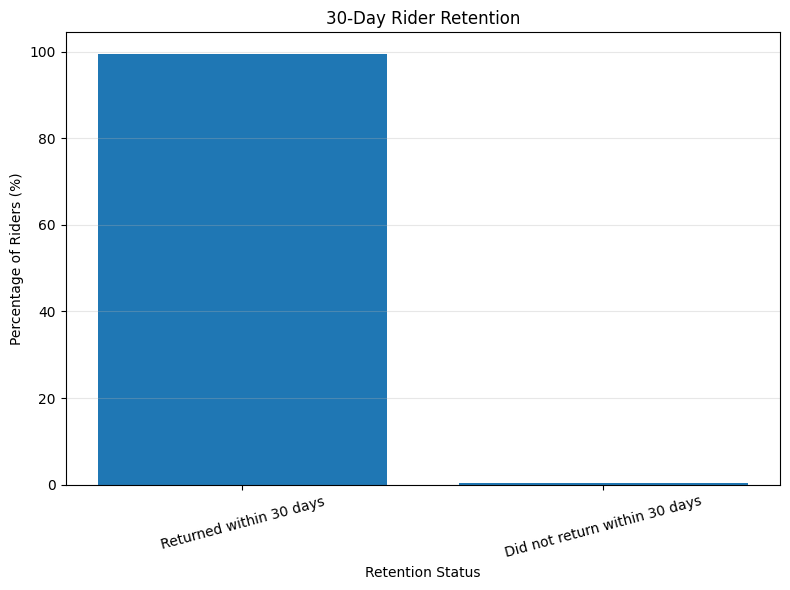

In [ ]:
# ============================================
# Q6 — Step 4: Overall 30-Day Retention
# ============================================

retention_summary = (
    rider_retention["returned_30d"]
    .value_counts()
    .rename(index={
        True: "Returned within 30 days",
        False: "Did not return within 30 days"
    })
    .reset_index()
)

retention_summary.columns = ["Retention Status", "Rider Count"]

total_riders = retention_summary["Rider Count"].sum()

retention_summary["Percentage"] = (
    retention_summary["Rider Count"] /
    total_riders * 100
)

print("30-DAY RETENTION SUMMARY")
print("=" * 60)

display(retention_summary)

retention_rate = (
    rider_retention["returned_30d"].mean() * 100
)

print(f"\nOverall 30-day retention rate: {retention_rate:.2f}%")

plt.figure(figsize=(8, 6))
plt.bar(
    retention_summary["Retention Status"],
    retention_summary["Percentage"]
)

plt.title("30-Day Rider Retention")
plt.xlabel("Retention Status")
plt.ylabel("Percentage of Riders (%)")
plt.xticks(rotation=15)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Q6 — Step 5: First Experience vs Retention
# ============================================

# Get each rider's first recorded event
first_events = (
    swap_events
    .sort_values(["rider_id", "event_ts"])
    .groupby("rider_id")
    .first()
    .reset_index()
)

# Keep useful first-experience fields
first_experience = first_events[
    [
        "rider_id",
        "event_type",
        "queue_wait_sec",
        "amount_charged_inr",
        "station_id",
        "attempt_seq"
    ]
].copy()

# Join retention outcome
retention_experience = rider_retention[
    ["rider_id", "returned_30d"]
].merge(
    first_experience,
    on="rider_id",
    how="left"
)

print("First-experience dataset created.")
print(f"Riders included: {len(retention_experience):,}")

print("\nAverage first queue wait by retention:")
display(
    retention_experience
    .groupby("returned_30d")["queue_wait_sec"]
    .agg(["count", "mean", "median"])
)

print("\nFirst event outcome by retention:")
display(
    pd.crosstab(
        retention_experience["event_type"],
        retention_experience["returned_30d"],
        normalize="columns"
    ) * 100
)

First-experience dataset created.
Riders included: 19,950

Average first queue wait by retention:


,count,mean,median
returned_30d,,,
False,98,271.397959,234.0
True,19852,242.753929,206.0



First event outcome by retention:


returned_30d,False,True
event_type,,
abandoned_queue,1.020408,1.702599
cancelled_by_rider,0.000000,0.533951
failed_no_charged_battery,1.020408,3.259117
failed_system_error,0.000000,0.231715
swap_completed,97.959184,94.272617


30-DAY RETURN RATE BY FIRST EVENT


,event_type,riders,returned_30d,return_rate_30d
1,cancelled_by_rider,106,106,100.000000
3,failed_system_error,46,46,100.000000
2,failed_no_charged_battery,648,647,99.845679
0,abandoned_queue,339,338,99.705015
4,swap_completed,18811,18715,99.489660


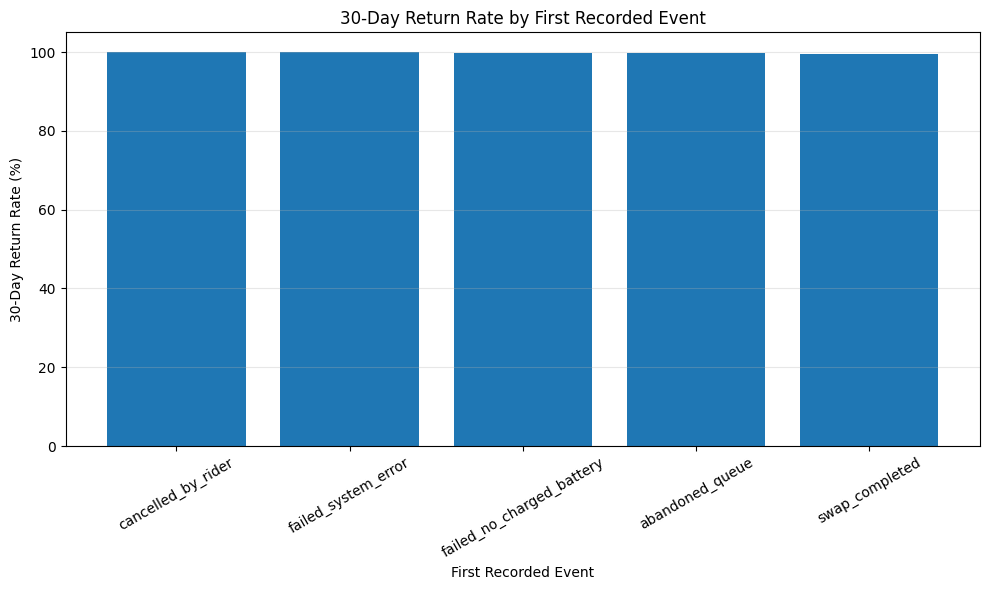

In [ ]:
# ============================================
# Q6 — Step 6: Return Rate by First Event
# ============================================

first_event_retention = (
    retention_experience
    .groupby("event_type")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

first_event_retention["return_rate_30d"] = (
    first_event_retention["returned_30d"] /
    first_event_retention["riders"] * 100
)

first_event_retention = first_event_retention.sort_values(
    "return_rate_30d",
    ascending=False
)

print("30-DAY RETURN RATE BY FIRST EVENT")
print("=" * 60)

display(first_event_retention)

plt.figure(figsize=(10, 6))

plt.bar(
    first_event_retention["event_type"],
    first_event_retention["return_rate_30d"]
)

plt.title("30-Day Return Rate by First Recorded Event")
plt.xlabel("First Recorded Event")
plt.ylabel("30-Day Return Rate (%)")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

30-DAY RETURN RATE BY FIRST WAIT-TIME GROUP


,wait_group,riders,returned_30d,avg_wait_sec,return_rate_30d
0,Shortest Wait,5031,5014,92.060425,99.662095
1,Short-Medium,4957,4931,171.709098,99.475489
2,Medium-Long,4976,4953,250.834807,99.537781
3,Longest Wait,4986,4954,457.937425,99.358203


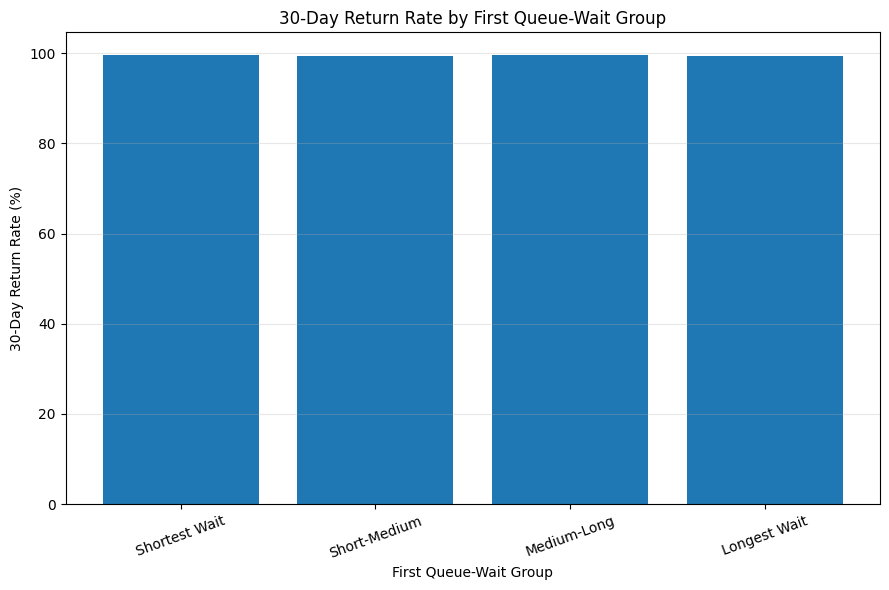

In [ ]:
# ============================================
# Q6 — Step 7: Queue Wait vs Retention
# ============================================

# Create queue-wait groups using quartiles
retention_experience["wait_group"] = pd.qcut(
    retention_experience["queue_wait_sec"],
    q=4,
    labels=["Shortest Wait", "Short-Medium", "Medium-Long", "Longest Wait"],
    duplicates="drop"
)

wait_retention = (
    retention_experience
    .groupby("wait_group", observed=False)
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum"),
        avg_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

wait_retention["return_rate_30d"] = (
    wait_retention["returned_30d"] /
    wait_retention["riders"] * 100
)

print("30-DAY RETURN RATE BY FIRST WAIT-TIME GROUP")
print("=" * 60)

display(wait_retention)

plt.figure(figsize=(9, 6))

plt.bar(
    wait_retention["wait_group"].astype(str),
    wait_retention["return_rate_30d"]
)

plt.title("30-Day Return Rate by First Queue-Wait Group")
plt.xlabel("First Queue-Wait Group")
plt.ylabel("30-Day Return Rate (%)")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Q6 — Step 8: Station Experience vs Retention
# ============================================

station_retention = (
    retention_experience
    .groupby("station_id")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum"),
        avg_first_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

station_retention["return_rate_30d"] = (
    station_retention["returned_30d"] /
    station_retention["riders"] * 100
)

# Focus on stations with enough first-time riders
station_retention_filtered = station_retention[
    station_retention["riders"] >= 100
].copy()

station_retention_filtered = station_retention_filtered.sort_values(
    "return_rate_30d"
)

print("STATION-LEVEL RETENTION")
print("=" * 60)

display(
    station_retention_filtered.head(10)
)

print("\nStations with highest return rates:")
display(
    station_retention_filtered
    .sort_values("return_rate_30d", ascending=False)
    .head(10)
)

STATION-LEVEL RETENTION


,station_id,riders,returned_30d,avg_first_wait_sec,return_rate_30d
145,STN-PUN-106,164,161,250.774390,98.170732
62,STN-HYD-063,169,166,250.887574,98.224852
19,STN-BLR-020,117,115,258.735043,98.290598
132,STN-PUN-093,186,183,250.774194,98.387097
77,STN-HYD-078,129,127,242.085271,98.449612
67,STN-HYD-068,196,193,250.040816,98.469388
140,STN-PUN-101,152,150,241.059211,98.684211
41,STN-DEL-042,160,158,252.718750,98.750000
9,STN-BLR-010,160,158,231.968750,98.750000
69,STN-HYD-070,255,252,246.615686,98.823529



Stations with highest return rates:


,station_id,riders,returned_30d,avg_first_wait_sec,return_rate_30d
91,STN-JAI-136,152,152,256.013158,100.0
94,STN-JAI-139,167,167,262.407186,100.0
75,STN-HYD-076,134,134,229.664179,100.0
74,STN-HYD-075,131,131,237.015267,100.0
68,STN-HYD-069,184,184,242.364130,100.0
66,STN-HYD-067,202,202,251.445545,100.0
70,STN-HYD-071,177,177,235.892655,100.0
48,STN-DEL-049,111,111,257.144144,100.0
63,STN-HYD-064,190,190,247.263158,100.0
49,STN-DEL-050,245,245,245.714286,100.0


## 9. Core Question 6 — Rider Retention / Root Cause Analysis

The retention analysis examined whether characteristics of a rider's first recorded experience were associated with returning within 30 days.

### Analysis Performed

* Calculated the 30-day return rate for riders with sufficient follow-up data.
* Examined first-event outcomes and their relationship with subsequent rider return.
* Compared first-experience queue waiting times across retention groups.
* Compared 30-day return rates across first queue-wait groups.
* Examined station-level differences in 30-day return rates for stations with sufficient rider volume.
* Used the first recorded rider experience as the reference point for retention analysis.

### Business Interpretation

The analysis helps identify aspects of the initial customer experience that are associated with later rider retention.

Differences in return rates across first-event outcomes, waiting-time groups, or stations can be used to identify areas for further operational investigation.

These results should not be interpreted as proof of a single cause of rider churn. Rider retention can be influenced by multiple factors, and the analysis is observational. Additional controlled analysis would be required to establish causal relationships.

### Retention Analysis Conclusion

The most useful operational approach is to identify the first-experience factors and locations associated with weaker return rates, then investigate those areas further using


# 10. Overall Findings and Business Recommendations

## Overall Findings

The analysis evaluated the VoltRelay Energy battery-swapping network across network performance, service experience, station performance, battery operations, pricing and partner economics, and rider retention.

The analysis provides an evidence-based view of operational patterns and identifies areas that can be investigated further.

### Key Business Areas

1. **Network Performance**

   * Monitored swap volume, completion rates, failure rates, abandonment, cancellation, and revenue over time.
   * Identified changes in network performance across the analysis period.

2. **Service Experience**

   * Examined queue waiting times, service failures, abandoned attempts, and station-level differences.
   * Identified locations and periods that may require operational investigation.

3. **Station Performance**

   * Compared station-level completion, failure, and waiting-time metrics.
   * Examined available station characteristics alongside operational performance.

4. **Battery and Equipment**

   * Examined battery health, usage intensity, charge-cycle information, and available supplier/manufacturer attributes.
   * Identified battery-level patterns that can support maintenance and monitoring.

5. **Pricing and Partner Economics**

   * Compared tariffs, pricing, discounts, revenue, and available fleet-partner activity.
   * Examined pricing and partner patterns over time.

6. **Rider Retention**

   * Measured 30-day rider return behavior.
   * Examined first-experience outcomes, waiting times, and station-level differences in relation to retention.

## Actionable Recommendations

Based on the observed patterns, VoltRelay Energy can prioritize:

* Monitoring high-volume stations with weaker service performance.
* Investigating stations with high failure rates or long queue waits.
* Using battery-health and usage indicators for preventive maintenance.
* Reviewing tariff and discount performance across customer segments and periods.
* Monitoring partner-level economics and operational contribution.
* Investigating first-experience factors associated with weaker rider retention.
* Repeating these analyses regularly as new operational data becomes available.

## Analytical Limitation

This analysis is observational. The relationships identified between operational factors, pricing, battery characteristics, and rider behavior should not be interpreted as causal effects without additional controlled analysis.

The recommendations are therefore intended as evidence-based areas for operational investigation and prioritization.
